# Deng control-volume reconstruction for the conforming fracture MMS (P0 multiplier)

This is the P0/DG0 multiplier variant of the conforming fracture MMS notebook. The Lagrange multiplier lives on an independent, coarser 1D mesh (`h_lambda ~ LAMBDA_COARSEN * h`), which restores inf-sup stability: a multiplier mesh that is too fine (including the equal-order P1/P1/P1 test and a P0 multiplier at `h_lambda = h`) gives a singular saddle point and an oscillatory `lambda_h` that corrupts the Deng reconstruction near the fracture tips. Because DOLFINx entity maps cannot couple an independent non-matching multiplier mesh through the mixed assembler, the four lambda-coupling blocks are hand-assembled and stitched onto the DOLFINx-assembled bulk and fracture blocks, then solved monolithically.


In [29]:
# ============================================================
# Configuration and imports
# ============================================================
from mpi4py import MPI
import numpy as np
import math
import time
import pathlib
import basix
import matplotlib.pyplot as plt
from tqdm import tqdm

from dolfinx import mesh, fem, geometry
from dolfinx.fem import petsc
from petsc4py import PETSc
try:
    from dolfinx.io import gmsh as gmshio
except ImportError:
    from dolfinx.io import gmshio
import ufl

# Matrix and fracture-pressure order. Use P1 here to match the nonconforming P0 notebooks.
# The multiplier remains DG0/P0 on the independent coarse line mesh.
order = 1
lambda_order = 0
Gamma_tag = 2
# Multiplier-mesh coarsening factor. h_lambda ~ LAMBDA_COARSEN * h; the
# Koppel-Martin inf-sup condition needs the P0 multiplier mesh not to be too fine;
# h_lambda = h was singular in this conforming setup, so use at least coarsen=2.
LAMBDA_COARSEN = 2

# Section 0: convergence analysis. Keep False for a quick diagnostic run.
RUN_CONVERGENCE = False
CONV_REFS = [3, 4,5,6,7]

# Three convergence cases run back-to-back by the Section 0 driver. `order` and
# `lambda_order` below are defaults for the standalone demo cells; the driver
# overrides them per case.
CASES = [
    {"name": "order1_P0", "order": 1, "lambda_order": 0},
    {"name": "order2_P0", "order": 2, "lambda_order": 0},
    {"name": "order2_P1", "order": 2, "lambda_order": 1},
]
RESULTS_DIR = pathlib.Path("deng_convergence_results")

# Main comparison run, matching the PINN MMS comparison table.
REF_DEMO = 6

# Deng post-processing/reconstruction is optional for this notebook.
# The fracture element residual below is a CG/LCG-level diagnostic and does not need it.
RUN_DENG_DEMO = False

# Jump/error summaries exclude the tip layer below.
TIP_FRAC = 0.10

# Residual-map color range. Values outside this range are saturated.
RK_LOG_VMIN = -10.0
RK_LOG_VMAX = -1.0
RK_CBAR_TICKS = np.arange(RK_LOG_VMIN, RK_LOG_VMAX + 1, 1, dtype=float)

Lx, Ly = 1.0, 1.0
x_start, x_end = 0.0, 1.0
y_start, y_end = 0.0, 1.0
ALPHA = 1.0
K_M_VALUE = 1.0
K_F_VALUE = 100.0

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})


In [30]:
# ============================================================
# MMS data
# ============================================================
def mesh_path_for_ref(ref):
    name = f"regular_mesh_with_fracture_{ref}.msh"
    candidates = [
        pathlib.Path.cwd() / name,
        pathlib.Path.cwd() / "fenicsx/code/fracture problem" / name,
        pathlib.Path("fenicsx/code/fracture problem") / name,
    ]
    for p in candidates:
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"Could not find {name}; tried: " + ", ".join(str(p) for p in candidates))


def q_exact_xy(x0, y0):
    return np.sin(np.pi * x0) * np.sin(np.pi * y0)


def r_exact_xy(x0, y0):
    return (x0 - y0) / np.sqrt(2.0)


def p_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    return q + ALPHA * np.abs(r_exact_xy(x0, y0)) * q


def p_m_exact_fn(x):
    return p_m_exact_xy(x[0], x[1])


def p_f_exact_fn(t):
    return np.sin(np.pi * t) ** 2


def lam_exact_fn(t):
    return -2.0 * ALPHA * np.sin(np.pi * t) ** 2


def f_m_exact_xy(x0, y0):
    q = q_exact_xy(x0, y0)
    r = r_exact_xy(x0, y0)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    return (
        2.0 * np.pi**2 * q
        + 2.0 * ALPHA * np.pi**2 * np.abs(r) * q
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r * np.sin(np.pi * (y0 - x0))
    )


def f_m_exact_points(points):
    points = np.asarray(points, dtype=float)
    return f_m_exact_xy(points[:, 0], points[:, 1])


def f_callable(x):
    return f_m_exact_xy(x[0], x[1])


def ff_callable(x):
    t = x[0]
    return -K_F_VALUE * np.pi**2 * np.cos(2.0 * np.pi * t) + lam_exact_fn(t)


def k_callable(x):
    return (x[0] * 0.0 + K_M_VALUE)[np.newaxis, :]


def exact_grad_p(points):
    pts = np.asarray(points, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    q = q_exact_xy(x, y)
    r = r_exact_xy(x, y)
    abs_r = np.abs(r)
    sign_r = np.where(r >= 0.0, 1.0, -1.0)
    dqdx = np.pi * np.cos(np.pi * x) * np.sin(np.pi * y)
    dqdy = np.pi * np.sin(np.pi * x) * np.cos(np.pi * y)
    drdx = 1.0 / np.sqrt(2.0)
    drdy = -1.0 / np.sqrt(2.0)
    grad = np.zeros((len(pts), 2), dtype=float)
    grad[:, 0] = dqdx + ALPHA * (sign_r * drdx * q + abs_r * dqdx)
    grad[:, 1] = dqdy + ALPHA * (sign_r * drdy * q + abs_r * dqdy)
    return grad


def exact_q(points):
    return -K_M_VALUE * exact_grad_p(points)

In [31]:
# ============================================================
# LCG solve for the conforming fracture MMS
#
# The Lagrange multiplier lambda is piecewise-constant (P0) on an INDEPENDENT,
# coarser 1D mesh (h_lambda ~ LAMBDA_COARSEN * h).  A multiplier mesh that is
# too fine, including h_lambda = h for DG0/P0, is inf-sup unstable here -- the saddle
# point is singular (a spurious lambda mode survives the BCs), which produces
# an oscillatory lambda_h and wrecks the Deng reconstruction.  Following
# Koppel-Martin we coarsen the multiplier mesh.  DOLFINx entity maps cannot
# couple an independent non-matching mesh through the mixed assembler, so the
# four lambda-coupling blocks are hand-assembled and stitched onto the
# DOLFINx-assembled bulk (p_m) and fracture (p_f) blocks.
# ============================================================
def fracture_origin_tau():
    frac_a = np.array([x_start, y_start], dtype=float)
    frac_b = np.array([x_end, y_end], dtype=float)
    tau = frac_b - frac_a
    nrm = np.linalg.norm(tau)
    if nrm == 0.0:
        raise ValueError("zero-length fracture")
    return frac_a, tau / nrm


def make_multiplier_line_mesh(points2d):
    """Independent 1D interval mesh embedded in 2D through the ordered nodes."""
    pts = np.asarray(points2d, dtype=np.float64)
    n_cells = len(pts) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    try:
        return mesh.create_mesh(MPI.COMM_SELF, cells, coord_el, pts)
    except (TypeError, AttributeError, IndexError):
        return mesh.create_mesh(MPI.COMM_SELF, cells, pts, coord_el)


def coarse_multiplier_nodes(gamma, coarsen):
    """Coarsen the conforming fracture vertices by `coarsen` (h_lambda ~ coarsen*h)."""
    frac_a, tau = fracture_origin_tau()
    gamma.topology.create_connectivity(gamma.topology.dim, 0)
    geom_g = gamma.geometry.x[:, :2]
    s_v = (geom_g - frac_a) @ tau
    s_sorted = np.sort(s_v)
    idx = list(range(0, len(s_sorted), max(int(coarsen), 1)))
    if idx[-1] != len(s_sorted) - 1:
        idx.append(len(s_sorted) - 1)
    coarse_s = s_sorted[idx]
    coarse_pts = frac_a[None, :] + coarse_s[:, None] * tau[None, :]
    return coarse_s, coarse_pts


def solve_lcg_mms(ref, verbose=False):
    filename = mesh_path_for_ref(ref)
    msh, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, MPI.COMM_WORLD, 0, gdim=2
    )[0:3]
    comm = msh.comm
    tdim = msh.topology.dim
    fdim = tdim - 1
    omega = msh

    gamma_entities = facet_markers.find(Gamma_tag)
    gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(
        omega, fdim, gamma_entities
    )[0:3]

    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))

    # Coarse independent multiplier mesh.  DG0 for the P0 multiplier;
    # continuous Lagrange for the P1 multiplier (lambda_order >= 1).
    frac_a, tau = fracture_origin_tau()
    coarse_s, coarse_pts = coarse_multiplier_nodes(gamma, LAMBDA_COARSEN)
    gamma_l = make_multiplier_line_mesh(coarse_pts)
    lam_family = ("DG", 0) if lambda_order == 0 else ("Lagrange", lambda_order)
    V_l = fem.functionspace(gamma_l, lam_family)

    n_m = V_m.dofmap.index_map.size_local
    n_f = V_f.dofmap.index_map.size_local
    n_l = V_l.dofmap.index_map.size_local

    # Per-coarse-cell multiplier data: arclength endpoints (connectivity order)
    # and the cell's lambda dofs.  geo_order maps geometric interval k (between
    # coarse_s[k] and coarse_s[k+1]) to its gamma_l cell index, robust to any
    # mesh reordering.  _lam_basis evaluates the multiplier shape functions on
    # the reference interval (constant 1 for P0; linear for P1).
    n_intervals = len(coarse_s) - 1
    lam_elem = None if lambda_order == 0 else basix.create_element(
        basix.ElementFamily.P, basix.CellType.interval, lambda_order)

    def _lam_basis(r_col):
        r_col = np.asarray(r_col, dtype=float)
        if lambda_order == 0:
            return np.ones((r_col.shape[0], 1))
        return _tab(lam_elem, 0, r_col)[0]

    gamma_l.topology.create_connectivity(1, 0)
    c2v_l = gamma_l.topology.connectivity(1, 0)
    geom_l = gamma_l.geometry.x[:, :2]
    coarse_cell_s = []
    coarse_cell_ldofs = []
    for cl in range(gamma_l.topology.index_map(1).size_local):
        lv = np.asarray(c2v_l.links(cl), dtype=np.int32)
        coarse_cell_s.append(((geom_l[lv] - frac_a) @ tau).astype(float))
        coarse_cell_ldofs.append(np.asarray(V_l.dofmap.cell_dofs(cl), dtype=np.int32))
    geo_order = np.argsort([float(np.min(sv)) for sv in coarse_cell_s])

    # Data and MMS source.
    f_m = fem.Function(V_m, name="f_m"); f_m.interpolate(f_callable)
    f_f = fem.Function(V_f, name="f_f"); f_f.interpolate(ff_callable)
    k_m = fem.Function(V_m, name="k_m"); k_m.interpolate(k_callable)

    x = ufl.SpatialCoordinate(omega)
    q_ufl = ufl.sin(np.pi * x[0]) * ufl.sin(np.pi * x[1])
    r_ufl = (x[0] - x[1]) / np.sqrt(2.0)
    abs_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), r_ufl, -r_ufl)
    sign_r_ufl = ufl.conditional(ufl.ge(r_ufl, 0.0), 1.0, -1.0)
    f_m_ufl = (
        2.0 * np.pi**2 * q_ufl
        + 2.0 * ALPHA * np.pi**2 * abs_r_ufl * q_ufl
        - ALPHA * np.sqrt(2.0) * np.pi * sign_r_ufl * ufl.sin(np.pi * (x[1] - x[0]))
    )

    dx = ufl.Measure("dx", domain=omega)
    dx_f = ufl.Measure("dx", domain=gamma)

    # Bulk and fracture blocks via DOLFINx (BCs applied later, on the monolith).
    pm_t = ufl.TrialFunction(V_m); phi = ufl.TestFunction(V_m)
    A_mm = petsc.assemble_matrix(fem.form(ufl.inner(k_m * ufl.grad(pm_t), ufl.grad(phi)) * dx))
    A_mm.assemble()
    L_m_vec = petsc.assemble_vector(fem.form(f_m_ufl * phi * dx)); L_m_vec.assemble()

    pf_t = ufl.TrialFunction(V_f); psi = ufl.TestFunction(V_f)
    A_ff = petsc.assemble_matrix(fem.form(K_F_VALUE * ufl.inner(ufl.grad(pf_t), ufl.grad(psi)) * dx_f))
    A_ff.assemble()
    L_f_vec = petsc.assemble_vector(fem.form(f_f * psi * dx_f)); L_f_vec.assemble()

    # Hand-assembled lambda coupling.  The multiplier is DG0/P0 on the coarse
    # independent line mesh, while the matrix/fracture trace uses the current
    # Lagrange order.  Interval-basis quadrature gives l/2,l/2 for P1 and
    # l/6,2l/3,l/6 for P2 on a fine fracture facet.
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]

    def coord_key(x):
        return (round(float(x[0]), 10), round(float(x[1]), 10))

    dof_m = {coord_key(c): i for i, c in enumerate(coords_m)}
    dof_f = {coord_key(c): i for i, c in enumerate(coords_f)}
    gamma.topology.create_connectivity(fdim, 0)
    c2v_g = gamma.topology.connectivity(fdim, 0)
    geom_g = gamma.geometry.x[:, :2]
    # Coupling integrals int_Gamma (lambda_basis) (trace_basis) ds, split at the
    # coarse multiplier nodes so each sub-segment lies in a single coarse cell.
    # General over the multiplier order: W[a, j] = int phi_lam_a * phi_trace_j.
    interval_elem = basix.create_element(basix.ElementFamily.P, basix.CellType.interval, order)
    X_cpl, w_cpl = basix.make_quadrature(basix.CellType.interval, max(4, 2 * order + 2 * lambda_order + 2))
    r_cpl = X_cpl[:, 0]
    C_m = {}; C_f = {}

    for ci in range(gamma.topology.index_map(fdim).size_local):
        verts = np.asarray(c2v_g.links(ci), dtype=np.int32)
        pts = geom_g[verts]
        s0, s1 = ((pts - frac_a) @ tau).astype(float)
        if abs(s1 - s0) < 1e-14:
            continue
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
        inner = coarse_s[(coarse_s > lo + 1e-14) & (coarse_s < hi - 1e-14)]
        if s1 < s0:
            inner = inner[::-1]
        knots = np.r_[s0, inner, s1]
        for a_s, b_s in zip(knots[:-1], knots[1:]):
            if abs(b_s - a_s) < 1e-14:
                continue
            seg_len = abs(b_s - a_s)
            s_q = a_s + (b_s - a_s) * r_cpl
            k = int(np.clip(np.searchsorted(coarse_s, 0.5 * (a_s + b_s), side="right") - 1, 0, n_intervals - 1))
            lcell = int(geo_order[k])
            ldofs = coarse_cell_ldofs[lcell]
            cs0, cs1 = coarse_cell_s[lcell]
            phi_tr = _tab(interval_elem, 0, ((s_q - s0) / (s1 - s0))[:, None])[0]   # (nq, order+1)
            phi_lm = _lam_basis(((s_q - cs0) / (cs1 - cs0))[:, None])               # (nq, lambda_order+1)
            W = seg_len * np.einsum("q,qa,qj->aj", w_cpl, phi_lm, phi_tr)
            for a, ld in enumerate(ldofs):
                for j, fd in enumerate(fdofs):
                    fkey = coord_key(coords_f[int(fd)])
                    if fkey not in dof_m:
                        raise KeyError(f"Could not match fracture trace dof {fkey} in matrix space.")
                    md = int(dof_m[fkey])
                    val = float(W[a, j])
                    C_m[(int(ld), md)] = C_m.get((int(ld), md), 0.0) + val
                    C_f[(int(ld), int(fd))] = C_f.get((int(ld), int(fd)), 0.0) + val

    # Stitch the monolithic saddle-point system.
    N = n_m + n_f + n_l
    off_m, off_f, off_l = 0, n_m, n_m + n_f
    A = PETSc.Mat().createAIJ((N, N), comm=PETSc.COMM_SELF)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()

    def _insert_block(sub, roff, coff):
        ai, aj, av = sub.getValuesCSR()
        for r in range(len(ai) - 1):
            cols = aj[ai[r]:ai[r + 1]]
            if len(cols):
                A.setValues([roff + r], (coff + cols).astype(np.int32),
                            av[ai[r]:ai[r + 1]], addv=PETSc.InsertMode.ADD_VALUES)

    _insert_block(A_mm, off_m, off_m)
    _insert_block(A_ff, off_f, off_f)
    for (ld, md), v in C_m.items():
        A.setValues([off_m + md], [off_l + ld], -v, addv=PETSc.InsertMode.ADD_VALUES)  # -int lambda*phi
        A.setValues([off_l + ld], [off_m + md], +v, addv=PETSc.InsertMode.ADD_VALUES)  # +int p_m*mu
    for (ld, fd), v in C_f.items():
        A.setValues([off_f + fd], [off_l + ld], +v, addv=PETSc.InsertMode.ADD_VALUES)  # +int lambda*psi
        A.setValues([off_l + ld], [off_f + fd], -v, addv=PETSc.InsertMode.ADD_VALUES)  # -int p_f*mu
    A.assemble()

    b = A.createVecRight()
    b.setValues(np.arange(off_m, off_m + n_m, dtype=np.int32), L_m_vec.getArray())
    b.setValues(np.arange(off_f, off_f + n_f, dtype=np.int32), L_f_vec.getArray())
    b.assemble()

    # Dirichlet BCs: p_m = 0 on the outer boundary, p_f = 0 at the two tips.
    tol = 1e-10
    bnd = np.where(
        np.isclose(coords_m[:, 0], 0.0, atol=tol) | np.isclose(coords_m[:, 0], Lx, atol=tol)
        | np.isclose(coords_m[:, 1], 0.0, atol=tol) | np.isclose(coords_m[:, 1], Ly, atol=tol)
    )[0].astype(np.int32)
    tips = np.where(
        (np.linalg.norm(coords_f - np.array([x_start, y_start]), axis=1) < 1e-8)
        | (np.linalg.norm(coords_f - np.array([x_end, y_end]), axis=1) < 1e-8)
    )[0].astype(np.int32)
    all_dofs = bnd.copy()  # V_m boundary dofs (off_m == 0)
    bc_idx = np.concatenate([off_m + bnd, off_f + tips]).astype(np.int32)
    x_bc = A.createVecRight(); x_bc.set(0.0); x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)

    # Monolithic LU solve.
    ksp = PETSc.KSP().create(PETSc.COMM_SELF)
    ksp.setOptionsPrefix(f"deng_frac_ref{ref}_")
    ksp.setOperators(A)
    ksp.setType(PETSc.KSP.Type.PREONLY)
    pc = ksp.getPC(); pc.setType(PETSc.PC.Type.LU)
    try:
        pc.setFactorSolverType("mumps")
    except Exception:
        pass
    x_sol = A.createVecRight()
    ksp.solve(b, x_sol)
    if ksp.getConvergedReason() < 0:
        raise RuntimeError(f"LU solve failed (KSP reason {ksp.getConvergedReason()})")
    sol = x_sol.getArray()
    iterations = 1

    p_m = fem.Function(V_m, name="p_m"); p_m.x.array[:] = sol[off_m:off_m + n_m]; p_m.x.scatter_forward()
    p_f = fem.Function(V_f, name="p_f"); p_f.x.array[:] = sol[off_f:off_f + n_f]; p_f.x.scatter_forward()
    lmbd = fem.Function(V_l, name="lmbd"); lmbd.x.array[:] = sol[off_l:off_l + n_l]; lmbd.x.scatter_forward()

    # Multiplier-sign selection and lambda L2 error on the coarse P0 intervals
    # (lmbd is on an independent mesh, so this is integrated in numpy).
    def _lam_err(sign):
        e = 0.0
        for k in range(n_intervals):
            lcell = int(geo_order[k])
            ldofs = coarse_cell_ldofs[lcell]
            cs0, cs1 = coarse_cell_s[lcell]
            ell = abs(cs1 - cs0)
            lam_nodal = lmbd.x.array[ldofs]
            for tg, wg in zip(_T_G, _W_G):
                val = float(np.dot(_lam_basis(np.array([[tg]]))[0], lam_nodal))
                pt = frac_a + (cs0 + (cs1 - cs0) * tg) * tau
                e += ell * wg * (sign * val - lam_exact_fn(pt[0])) ** 2
        return math.sqrt(e)
    err_lam_plus = _lam_err(1.0)
    err_lam_minus = _lam_err(-1.0)
    lambda_balance_sign = 1.0 if err_lam_plus <= err_lam_minus else -1.0
    err_lam = min(err_lam_plus, err_lam_minus)

    # Pressure L2 errors (DOLFINx).
    def sqrt_global(form_expr):
        local = fem.assemble_scalar(fem.form(form_expr))
        return np.sqrt(comm.allreduce(local, op=MPI.SUM))
    p_m_ex = fem.Function(V_m); p_m_ex.interpolate(p_m_exact_fn)
    p_f_ex = fem.Function(V_f); p_f_ex.interpolate(lambda xx: p_f_exact_fn(xx[0]))
    err_pm = sqrt_global((p_m - p_m_ex) ** 2 * dx)
    err_pf = sqrt_global((p_f - p_f_ex) ** 2 * dx_f)

    lam_t_nodes = np.sort(coarse_pts[:, 0])
    lam_s_nodes = np.sort(coarse_s)
    h_lambda = float(np.max(np.diff(lam_t_nodes)))
    h_lambda_arc = float(np.max(np.diff(lam_s_nodes)))

    if verbose:
        print(f"ref={ref}: n_m={n_m}, n_f={n_f}, n_lambda(P0)={n_l}, "
              f"h={1.0/2**ref:.3e}, h_lambda_arc={h_lambda_arc:.3e}, "
              f"h_lambda_arc/h={h_lambda_arc/(1.0/2**ref):.2f}")

    return {
        "ref": ref,
        "h": 1.0 / (2 ** ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "gamma_to_omega": gamma_to_omega,
        "gamma_vertex_to_omega": gamma_vertex_to_omega,
        "gamma_entities": gamma_entities,
        "cell_markers": cell_markers,
        "facet_markers": facet_markers,
        "Gamma_tag": Gamma_tag,
        "V": V_m,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_sol": p_m,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "f_m": f_m,
        "all_dofs": all_dofs,
        "iterations": iterations,
        "dofs": n_m,
        "dofs_lambda": n_l,
        "lambda_space": ("DG0" if lambda_order == 0 else f"P{lambda_order}"),
        "lambda_t_nodes": lam_t_nodes,
        "lambda_s_nodes": lam_s_nodes,
        "h_lambda": h_lambda,
        "h_lambda_arc": h_lambda_arc,
        "n_lambda": n_l,
        "dofs_total": n_m + n_f + n_l,
        "lambda_balance_sign": lambda_balance_sign,
        "err_pm": err_pm,
        "err_pf": err_pf,
        "err_lam": err_lam,
        "mesh_file": filename,
    }


In [32]:
# ============================================================
# Geometry, quadrature, and field-evaluation helpers
# ============================================================
def cell_centroid(coords):
    return np.mean(coords, axis=0)


def edge_length(a, b):
    return float(np.linalg.norm(b - a))


def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def outward_edge_normal(a, b, centroid):
    t = b - a
    n1 = np.array([t[1], -t[0]])
    n2 = -n1
    mid = 0.5 * (a + b)
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    norm = np.linalg.norm(chosen)
    return chosen / norm if norm > 0.0 else chosen


def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0.0:
        poly = poly[::-1]
    return poly


def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)


def _tab(elem, nderiv, pts):
    t = elem.tabulate(nderiv, np.atleast_2d(pts))
    return t[..., 0] if t.ndim == 4 else t


_T_G = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)])
_W_G = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0])
_T_GAUSS = np.array([(1.0 - 1.0 / np.sqrt(3.0)) / 2.0, (1.0 + 1.0 / np.sqrt(3.0)) / 2.0])
_W_GAUSS = np.array([0.5, 0.5])



def error_quadrature_degree(degree=None):
    return max(5, 2 * order + 4) if degree is None else int(degree)


def deng_reference_topology(poly_order):
    if poly_order not in (1, 2):
        raise NotImplementedError("This notebook supports Deng reconstruction for order = 1 or 2.")

    elem = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, poly_order)
    dof_ref = elem.points[:, :2]

    def find_dof(xy):
        xy = np.asarray(xy, dtype=float)
        dist = np.linalg.norm(dof_ref - xy, axis=1)
        idx = int(np.argmin(dist))
        if dist[idx] > 1e-10:
            raise RuntimeError(f"Could not find reference dof at {xy} for order {poly_order}.")
        return idx

    v0 = find_dof([0.0, 0.0])
    v1 = find_dof([1.0, 0.0])
    v2 = find_dof([0.0, 1.0])

    if poly_order == 1:
        sub_tris = [[v0, v1, v2]]
        boundary_subedges = [
            (v0, v1, (0, 1)),
            (v1, v2, (1, 2)),
            (v2, v0, (2, 0)),
        ]
        edge_dof_sets = [frozenset([v0, v1]), frozenset([v1, v2]), frozenset([v2, v0])]
    else:
        m01 = find_dof([0.5, 0.0])
        m12 = find_dof([0.5, 0.5])
        m20 = find_dof([0.0, 0.5])
        sub_tris = [
            [v0, m01, m20],
            [v1, m01, m12],
            [v2, m20, m12],
            [m01, m12, m20],
        ]
        boundary_subedges = [
            (v0, m01, (0, 1)),
            (m01, v1, (0, 1)),
            (v1, m12, (1, 2)),
            (m12, v2, (1, 2)),
            (v2, m20, (2, 0)),
            (m20, v0, (2, 0)),
        ]
        edge_dof_sets = [
            frozenset([v0, v1, m01]),
            frozenset([v1, v2, m12]),
            frozenset([v2, v0, m20]),
        ]

    return {
        "elem": elem,
        "dof_ref": dof_ref,
        "vertex_to_dof": {0: v0, 1: v1, 2: v2},
        "sub_tris": [list(map(int, tri)) for tri in sub_tris],
        "boundary_subedges": [(int(a), int(b), tuple(map(int, lids))) for a, b, lids in boundary_subedges],
        "edge_dof_sets": edge_dof_sets,
    }


def prepare_fracture_geometry(ctx):
    omega = ctx["omega"]
    tdim = omega.topology.dim
    fdim = tdim - 1
    gdim = omega.geometry.dim
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0), (0, tdim)]:
        omega.topology.create_connectivity(*pair)

    c2v = omega.topology.connectivity(tdim, 0)
    cell_to_facet = omega.topology.connectivity(tdim, fdim)
    facet_to_cell = omega.topology.connectivity(fdim, tdim)
    facet_to_vertex = omega.topology.connectivity(fdim, 0)

    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    omega_geometry = omega.geometry.x[:, :2]
    local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]
    cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
    cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
    cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
    h_est = float(np.sqrt(np.mean(cell_areas)))
    facet_by_vertices = {frozenset(int(v) for v in facet_to_vertex.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set(int(f) for f in ctx["facet_markers"].find(ctx["Gamma_tag"]))

    coords = omega.geometry.x
    xmin, xmax = coords[:, 0].min(), coords[:, 0].max()
    ymin, ymax = coords[:, 1].min(), coords[:, 1].max()
    frac_a = np.array([x_start, y_start], dtype=float)
    frac_b = np.array([x_end, y_end], dtype=float)
    tau = unit(frac_b - frac_a)
    normal = np.array([-tau[1], tau[0]], dtype=float)
    L_gamma = float(np.linalg.norm(frac_b - frac_a))
    t_min, t_max = extend_line_to_bbox(frac_a, tau, np.array([xmin, xmax, ymin, ymax], dtype=float))
    ghost_start = frac_a + t_min * tau
    ghost_end = frac_a + t_max * tau

    Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
    interp_points = Wq.element.interpolation_points
    if callable(interp_points):
        interp_points = interp_points()
    q_cg_expr = fem.Expression(-ctx["k_m"] * ufl.grad(ctx["p_sol"]), interp_points)
    q_cg_fun = fem.Function(Wq, name="q_cg")
    q_cg_fun.interpolate(q_cg_expr)

    def signed_distance_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ normal

    def s_coord_np(points):
        return (np.asarray(points, dtype=float) - frac_a) @ tau

    def real_points_np(s):
        s = np.asarray(s, dtype=float).reshape(-1)
        return frac_a[None, :] + s[:, None] * tau[None, :]

    def ghost_points_np(n_each=160):
        pts = []
        if -t_min > 1e-14:
            s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
            pts.append(frac_a[None, :] + s_left[:, None] * tau[None, :])
        if t_max - L_gamma > 1e-14:
            s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
            pts.append(frac_a[None, :] + s_right[:, None] * tau[None, :])
        return np.vstack(pts) if pts else np.zeros((0, 2))

    return {
        "tdim": tdim,
        "fdim": fdim,
        "gdim": gdim,
        "c2v": c2v,
        "cell_to_facet": cell_to_facet,
        "facet_to_cell": facet_to_cell,
        "facet_to_vertex": facet_to_vertex,
        "num_cells": num_cells,
        "num_facets": num_facets,
        "omega_geometry": omega_geometry,
        "local_cell_vertices": local_cell_vertices,
        "cell_polys": cell_polys,
        "cell_centroids": cell_centroids,
        "cell_areas": cell_areas,
        "h_est": h_est,
        "facet_by_vertices": facet_by_vertices,
        "gamma_facet_set": gamma_facet_set,
        "FRAC_A": frac_a,
        "FRAC_B": frac_b,
        "tau_np": tau,
        "normal_np": normal,
        "L_gamma": L_gamma,
        "GHOST_START": ghost_start,
        "GHOST_END": ghost_end,
        "signed_distance_np": signed_distance_np,
        "s_coord_np": s_coord_np,
        "real_points_np": real_points_np,
        "ghost_points_np": ghost_points_np,
        "q_cg_fun": q_cg_fun,
    }


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(ctx, gdata, points):
    vals = eval_fem_function(gdata["q_cg_fun"], points, ctx["omega"])
    return vals[:, :2]


In [33]:
# ============================================================
# Fracture multiplier source terms
# ============================================================
def multiplier_interval_data(ctx):
    V_l = ctx["V_l"]
    gamma_l = ctx.get("gamma_l", ctx["gamma"])
    tdim_l = gamma_l.topology.dim
    gamma_l.topology.create_connectivity(tdim_l, 0)
    c2v_l = gamma_l.topology.connectivity(tdim_l, 0)
    geom_l = gamma_l.geometry.x[:, :2]
    frac_a, tau = fracture_origin_tau()
    vals_raw = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array

    records = []
    n_cells = gamma_l.topology.index_map(tdim_l).size_local
    for ci in range(n_cells):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        if len(verts) < 2 or len(ldofs) != 1:
            continue
        pts = geom_l[verts]
        t_cell = pts[:, 0]
        s_cell = (pts - frac_a) @ tau
        records.append((
            float(np.min(t_cell)),
            float(np.max(t_cell)),
            float(np.min(s_cell)),
            float(np.max(s_cell)),
            float(vals_raw[int(ldofs[0])]),
        ))

    if not records:
        raise RuntimeError("Could not build DG0 multiplier interval data.")

    records.sort(key=lambda r: r[0])
    rec = np.asarray(records, dtype=float)
    t_nodes = np.asarray(ctx.get("lambda_t_nodes", []), dtype=float)
    if len(t_nodes) != len(rec) + 1:
        t_nodes = np.unique(np.round(np.r_[rec[:, 0], rec[:, 1]], decimals=14))
        t_nodes.sort()
    return {
        "t0": rec[:, 0],
        "t1": rec[:, 1],
        "s0": rec[:, 2],
        "s1": rec[:, 3],
        "values": rec[:, 4],
        "t_nodes": t_nodes,
    }


def make_lambda_evaluator(ctx):
    V_l = ctx["V_l"]
    first_dofs = np.asarray(V_l.dofmap.cell_dofs(0), dtype=np.int32)

    if len(first_dofs) == 1:
        data = multiplier_interval_data(ctx)
        t_nodes = data["t_nodes"]
        vals = data["values"]

        def lam_at_points(points):
            pts = np.asarray(points, dtype=float)
            t = pts[:, 0]
            idx = np.searchsorted(t_nodes, t, side="right") - 1
            idx = np.clip(idx, 0, len(vals) - 1)
            return vals[idx]

        lam_at_points.is_piecewise_constant = True
        lam_at_points.t_nodes = t_nodes
        return lam_at_points

    coords = V_l.tabulate_dof_coordinates()[:, :2]
    t_nodes = coords[:, 0]
    vals = ctx["lambda_balance_sign"] * ctx["lmbd"].x.array[:len(t_nodes)]
    order_idx = np.argsort(t_nodes)
    t_sorted = t_nodes[order_idx]
    vals_sorted = vals[order_idx]

    def lam_at_points(points):
        pts = np.asarray(points, dtype=float)
        return np.interp(pts[:, 0], t_sorted, vals_sorted)

    lam_at_points.is_piecewise_constant = False
    lam_at_points.t_nodes = np.unique(np.round(t_sorted, decimals=14))
    return lam_at_points


def _integrate_lambda_quadrature(a, b, lambda_at_points):
    seg_len = edge_length(a, b)
    if seg_len == 0.0:
        return 0.0
    pts = np.array([a + t * (b - a) for t in _T_G], dtype=float)
    vals = lambda_at_points(pts)
    return seg_len * float(np.dot(_W_G, vals))


def integrate_lambda_segment(a, b, lambda_at_points):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if edge_length(a, b) == 0.0:
        return 0.0

    if getattr(lambda_at_points, "is_piecewise_constant", False):
        t_nodes = np.asarray(lambda_at_points.t_nodes, dtype=float)
        ta = float(a[0])
        tb = float(b[0])
        if abs(tb - ta) > 1e-14:
            lo, hi = (ta, tb) if ta <= tb else (tb, ta)
            inner = t_nodes[(t_nodes > lo + 1e-14) & (t_nodes < hi - 1e-14)]
            if tb < ta:
                inner = inner[::-1]
            knots = np.r_[ta, inner, tb]
            total = 0.0
            for t0, t1 in zip(knots[:-1], knots[1:]):
                r0 = (t0 - ta) / (tb - ta)
                r1 = (t1 - ta) / (tb - ta)
                p0 = a + r0 * (b - a)
                p1 = a + r1 * (b - a)
                pm = 0.5 * (p0 + p1)
                total += edge_length(p0, p1) * float(lambda_at_points(pm[None, :])[0])
            return float(total)

    return _integrate_lambda_quadrature(a, b, lambda_at_points)


def lambda_h_on_s(ctx, gdata, s_query):
    pts = gdata["real_points_np"](s_query)
    return make_lambda_evaluator(ctx)(pts)


def build_fracture_cv_source(ctx, gdata):
    V = ctx["V"]
    f2v = gdata["facet_to_vertex"]
    geom = gdata["omega_geometry"]
    coords_d = V.tabulate_dof_coordinates()[:, :2]
    ndofs = V.dofmap.index_map.size_local
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    def coord_key(x):
        return (round(float(x[0]), 10), round(float(x[1]), 10))

    dof_by_coord = {coord_key(c): i for i, c in enumerate(coords_d[:ndofs])}
    lambda_cv = np.zeros(ndofs, dtype=float)
    fracture_dofs = np.zeros(ndofs, dtype=bool)

    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        if order == 1:
            trace_points = [x0, x1]
        elif order == 2:
            trace_points = [x0, 0.5 * (x0 + x1), x1]
        else:
            raise NotImplementedError("This notebook supports order = 1 or 2.")
        trace_dofs = [dof_by_coord[coord_key(p)] for p in trace_points]
        for (da, pa), (db, pb) in zip(zip(trace_dofs[:-1], trace_points[:-1]), zip(trace_dofs[1:], trace_points[1:])):
            pm = 0.5 * (pa + pb)
            lambda_cv[da] += integrate_lambda_segment(pa, pm, lambda_at_points)
            lambda_cv[db] += integrate_lambda_segment(pb, pm, lambda_at_points)
            fracture_dofs[da] = True
            fracture_dofs[db] = True
    return lambda_cv, fracture_dofs


def build_fracture_element_source(ctx, gdata):
    # Element-wise residuals require an element source split. This diagnostic uses
    # an equal side split of each fracture-facet integral; the Deng CV residual
    # below uses the native endpoint-control-volume split.
    f2v = gdata["facet_to_vertex"]
    f2c = gdata["facet_to_cell"]
    geom = gdata["omega_geometry"]
    nc = gdata["num_cells"]
    lambda_at_points = make_lambda_evaluator(ctx)
    gamma_facets = np.asarray(ctx["facet_markers"].find(ctx["Gamma_tag"]), dtype=np.int32)

    lambda_cell = np.zeros(nc, dtype=float)
    records = []
    for facet in gamma_facets:
        verts = np.asarray(f2v.links(int(facet)), dtype=np.int32)
        if len(verts) != 2:
            continue
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        I_e = integrate_lambda_segment(x0, x1, lambda_at_points)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < nc]
        if not adj:
            continue
        share = I_e / len(adj)
        s0 = float(gdata["s_coord_np"](x0[None, :])[0])
        s1 = float(gdata["s_coord_np"](x1[None, :])[0])
        if s1 < s0:
            s0, s1 = s1, s0
        for cell in adj:
            lambda_cell[cell] += share
            records.append((cell, s0, s1, share))
    frac_cell_ids = np.where(np.abs(lambda_cell) > 0.0)[0].astype(np.int32)
    return lambda_cell, frac_cell_ids, records


In [34]:
# ============================================================
# Deng local post-processing with fracture source terms
# ============================================================
def deng_postprocess_fracture(ctx):
    omega = ctx["omega"]
    V = ctx["V"]
    p_sol = ctx["p_sol"]
    lambda_at_points = make_lambda_evaluator(ctx)

    def f_at(x):
        return float(f_m_exact_xy(x[0], x[1]))

    def k_at(x):
        return float(K_M_VALUE)

    topo = deng_reference_topology(order)
    elem = topo["elem"]
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    boundary_subedges = topo["boundary_subedges"]
    v0 = topo["vertex_to_dof"][0]
    v1 = topo["vertex_to_dof"][1]
    v2 = topo["vertex_to_dof"][2]
    Nk = elem.dim

    X_iq, w_iq = basix.make_quadrature(basix.CellType.triangle, max(5, 2 * order + 3))
    nq_iq = len(w_iq)
    tab_iq = _tab(elem, 1, X_iq)
    phi_iq = tab_iq[0]
    ref_grads_iq = np.stack([tab_iq[1], tab_iq[2]], axis=2)

    tdim = omega.topology.dim
    fdim = tdim - 1
    for pair in [(tdim, 0), (tdim, fdim), (fdim, tdim), (fdim, 0)]:
        omega.topology.create_connectivity(*pair)
    ctv = omega.topology.connectivity(tdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)

    geom = omega.geometry.x[:, :2]
    num_cells = omega.topology.index_map(tdim).size_local
    num_facets = omega.topology.index_map(fdim).size_local
    local_cell_verts = np.array([ctv.links(c) for c in range(num_cells)])
    facet_by_vertices = {frozenset(int(v) for v in f2v.links(fi)): fi for fi in range(num_facets)}
    gamma_facet_set = set(int(f) for f in ctx["facet_markers"].find(ctx["Gamma_tag"]))

    def integrate_f_triangle(p0, p1, p2):
        Jsub = np.column_stack((p1 - p0, p2 - p0))
        det_sub = abs(np.linalg.det(Jsub))
        pts = p0 + X_iq @ Jsub.T
        vals = np.array([f_at(x) for x in pts])
        return det_sub * float(np.dot(vals, w_iq))

    def add_fracture_terms(edge_info, dof_phys, source_t_gamma, source_phi_gamma):
        for ra, rb, facet in edge_info:
            if int(facet) not in gamma_facet_set:
                continue
            adj_cells = [int(c) for c in f2c.links(int(facet)) if int(c) < num_cells]
            side_weight = 1.0 / max(len(adj_cells), 1)
            a_ref = dof_ref[ra]
            b_ref = dof_ref[rb]
            a_phys = dof_phys[ra]
            b_phys = dof_phys[rb]
            m_phys = 0.5 * (a_phys + b_phys)

            source_t_gamma[ra] += side_weight * integrate_lambda_segment(a_phys, m_phys, lambda_at_points)
            source_t_gamma[rb] += side_weight * integrate_lambda_segment(b_phys, m_phys, lambda_at_points)

            seg_len = edge_length(a_phys, b_phys)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref + tg * (b_ref - a_ref)
                x_g = a_phys + tg * (b_phys - a_phys)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                lam_g = float(lambda_at_points(x_g[None, :])[0])
                source_phi_gamma += side_weight * wg * lam_g * phi_edge * seg_len

    dofmap = V.dofmap
    num_dofs = dofmap.index_map.size_local
    coef_glob = {i: [] for i in range(num_dofs)}
    local_fluxes = {}

    cell_cache = []
    for ci in range(num_cells):
        verts = local_cell_verts[ci]
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        cell_cache.append({
            "verts": verts,
            "coords": coords,
            "J": J,
            "invJ": np.linalg.inv(J),
            "uvals": p_sol.x.array[dofmap.cell_dofs(ci)],
        })

    def grad_uh_in_cell(ci, x_phys):
        data = cell_cache[ci]
        xi = data["invJ"] @ (x_phys - data["coords"][0])
        t_s = _tab(elem, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        phys_g = ref_g @ data["invJ"]
        return phys_g.T @ data["uvals"]

    def averaged_kgrad_dot_n(ci, facet, x_phys, n_out):
        val = k_at(x_phys) * grad_uh_in_cell(ci, x_phys)
        adj = [int(c) for c in f2c.links(int(facet)) if int(c) < num_cells]
        if len(adj) == 2 and int(facet) not in gamma_facet_set:
            nb = adj[0] if adj[1] == ci else adj[1]
            val_nb = k_at(x_phys) * grad_uh_in_cell(nb, x_phys)
            val = 0.5 * (val + val_nb)
        return float(np.dot(val, n_out))

    for ci in tqdm(range(num_cells), desc=f"Deng local fracture solves P{order}"):
        data = cell_cache[ci]
        coords = data["coords"]
        J = data["J"]
        abs_detJ = abs(np.linalg.det(J))
        invJ = data["invJ"]
        uvals = data["uvals"]
        cell_verts = data["verts"]
        dof_phys = coords[0] + dof_ref @ J.T
        cdofs = dofmap.cell_dofs(ci)

        phys_grads_iq = ref_grads_iq @ invJ
        grad_u_iq = np.einsum("qjd,j->qd", phys_grads_iq, uvals)
        X_phys_iq = coords[0] + X_iq @ J.T

        B = np.zeros((Nk, Nk))
        source_t_matrix = np.zeros(Nk)
        source_phi_matrix = np.zeros(Nk)
        source_t_gamma = np.zeros(Nk)
        source_phi_gamma = np.zeros(Nk)
        a_term = np.zeros(Nk)
        e_I = np.zeros(Nk)
        e_phi = np.zeros(Nk)

        for q in range(nq_iq):
            fq = f_at(X_phys_iq[q])
            kq = k_at(X_phys_iq[q])
            source_phi_matrix += abs_detJ * w_iq[q] * fq * phi_iq[q]
            a_term += abs_detJ * w_iq[q] * kq * (phys_grads_iq[q] @ grad_u_iq[q])

        for sub_tri in sub_tris:
            sub_dr = dof_ref[sub_tri]
            sub_dp = dof_phys[sub_tri]
            c_ref = np.mean(sub_dr, axis=0)
            c_phys = np.mean(sub_dp, axis=0)

            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                midA_r = 0.5 * (dof_ref[gi] + dof_ref[oa])
                midB_r = 0.5 * (dof_ref[gi] + dof_ref[ob])
                midA_p = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB_p = 0.5 * (dof_phys[gi] + dof_phys[ob])

                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], midA_p, c_phys)
                source_t_matrix[gi] += integrate_f_triangle(dof_phys[gi], c_phys, midB_p)

                nA = normal_from_C_to_ti(c_phys, midA_p, dof_phys[gi])
                nB = normal_from_C_to_ti(c_phys, midB_p, dof_phys[gi])
                lenA = edge_length(c_phys, midA_p)
                lenB = edge_length(c_phys, midB_p)

                for (a_r, a_p, b_r, b_p, n_s, l_s) in [
                    (c_ref, c_phys, midA_r, midA_p, nA, lenA),
                    (c_ref, c_phys, midB_r, midB_p, nB, lenB),
                ]:
                    for tg, wg in zip(_T_G, _W_G):
                        seg_r = a_r + tg * (b_r - a_r)
                        x_p = a_p + tg * (b_p - a_p)
                        k_g = k_at(x_p)
                        t_s = _tab(elem, 1, seg_r)
                        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
                        phys_g = ref_g @ invJ
                        B[gi, :] += wg * (-k_g * (phys_g @ n_s)) * l_s

        centroid_tau = np.mean([dof_phys[v0], dof_phys[v1], dof_phys[v2]], axis=0)
        edge_info = []
        edge_lookup = {}
        for ra, rb, (la, lb) in boundary_subedges:
            n_out = outward_edge_normal(dof_phys[ra], dof_phys[rb], centroid_tau)
            facet = facet_by_vertices[frozenset([int(cell_verts[la]), int(cell_verts[lb])])]
            edge_info.append((ra, rb, facet, n_out))
            edge_lookup[frozenset([ra, rb])] = (n_out, facet)

        add_fracture_terms([(ra, rb, facet) for ra, rb, facet, _ in edge_info], dof_phys, source_t_gamma, source_phi_gamma)

        for sub_tri in sub_tris:
            for li, gi in enumerate(sub_tri):
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                for neighbor in [oa, ob]:
                    info = edge_lookup.get(frozenset([gi, neighbor]))
                    if info is None:
                        continue
                    n_out, facet = info
                    if int(facet) in gamma_facet_set:
                        continue
                    a_phys_e = dof_phys[gi]
                    b_phys_e = 0.5 * (dof_phys[gi] + dof_phys[neighbor])
                    seg_len = edge_length(a_phys_e, b_phys_e)
                    for tg, wg in zip(_T_G, _W_G):
                        x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                        e_I[gi] += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * seg_len

        for ra, rb, facet, n_out in edge_info:
            if int(facet) in gamma_facet_set:
                continue
            a_ref_e = dof_ref[ra]
            b_ref_e = dof_ref[rb]
            a_phys_e = dof_phys[ra]
            b_phys_e = dof_phys[rb]
            seg_len = edge_length(a_phys_e, b_phys_e)
            for tg, wg in zip(_T_G, _W_G):
                xi_g = a_ref_e + tg * (b_ref_e - a_ref_e)
                x_phys_g = a_phys_e + tg * (b_phys_e - a_phys_e)
                phi_edge = _tab(elem, 0, xi_g)[0, 0]
                e_phi += wg * averaged_kgrad_dot_n(ci, facet, x_phys_g, n_out) * phi_edge * seg_len

        source_t = source_t_matrix + source_t_gamma
        source_phi = source_phi_matrix + source_phi_gamma
        rhs = source_t - source_phi + a_term + e_I - e_phi

        coeffs, *_ = np.linalg.lstsq(B, rhs, rcond=None)
        mass_vec = abs_detJ * (w_iq @ phi_iq)
        area = float(np.sum(mass_vec))
        if area > 0.0:
            coeffs += (float(np.dot(mass_vec, uvals)) - float(np.dot(mass_vec, coeffs))) / area

        for li, gd in enumerate(cdofs):
            if int(gd) < num_dofs:
                coef_glob[int(gd)].append(coeffs[li])

        t_c = _tab(elem, 1, np.array([1.0 / 3.0, 1.0 / 3.0]))
        ref_g_c = np.stack([t_c[1, 0], t_c[2, 0]], axis=1)
        phys_gc = ref_g_c @ invJ
        q_rec = -k_at(np.mean(coords, axis=0)) * (phys_gc.T @ coeffs)

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "q_rec": q_rec,
            "invJ": invJ,
            "cell_verts": cell_verts,
            "coords": coords,
            "dof_phys": dof_phys.copy(),
            "rhs": rhs.copy(),
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "source_t_matrix": source_t_matrix.copy(),
            "source_phi_matrix": source_phi_matrix.copy(),
            "source_t_gamma": source_t_gamma.copy(),
            "source_phi_gamma": source_phi_gamma.copy(),
            "a_term": a_term.copy(),
            "e_term": (e_I - e_phi).copy(),
            "sub_tris": sub_tris,
            "boundary_subedges": boundary_subedges,
            "vertex_to_dof": topo["vertex_to_dof"].copy(),
            "v_to_dof": topo["vertex_to_dof"].copy(),
        }

    p_rec_arr = np.zeros(num_dofs)
    for gd, vals in coef_glob.items():
        if vals:
            p_rec_arr[gd] = np.mean(vals)

    return local_fluxes, coef_glob, p_rec_arr


In [35]:
# ============================================================
# Residuals, errors, rates, and plotting helpers
# ============================================================
def _seg_flux_rec(a_phys, b_phys, n_out, coeffs, invJ, coords0, elem_):
    seg_len = edge_length(a_phys, b_phys)
    flux = 0.0
    for tg, wg in zip(_T_GAUSS, _W_GAUSS):
        x = a_phys + tg * (b_phys - a_phys)
        xi = invJ @ (x - coords0)
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ invJ).T @ coeffs
        flux += wg * (-K_M_VALUE * np.dot(grad_uh, n_out)) * seg_len
    return float(flux)


def q_rec_numpy(ctx, local_fluxes, gdata, points):
    omega = ctx["omega"]
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(omega, omega.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(omega, candidates, pts3)
    out = np.full((points.shape[0], 2), np.nan, dtype=float)
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) == 0:
            continue
        ci = int(links[0])
        if ci not in local_fluxes:
            continue
        data = local_fluxes[ci]
        x = points[i]
        xi = data["invJ"] @ (x - data["coords"][0])
        t_s = _tab(elem_, 1, xi)
        ref_g = np.stack([t_s[1, 0], t_s[2, 0]], axis=1)
        grad_uh = (ref_g @ data["invJ"]).T @ data["coeffs"]
        out[i] = -K_M_VALUE * grad_uh
    return out


def boundary_vertex_mask(omega):
    tdim = omega.topology.dim
    fdim = tdim - 1
    omega.topology.create_connectivity(fdim, tdim)
    omega.topology.create_connectivity(fdim, 0)
    f2c = omega.topology.connectivity(fdim, tdim)
    f2v = omega.topology.connectivity(fdim, 0)
    nv = omega.topology.index_map(0).size_local
    nf = omega.topology.index_map(fdim).size_local
    is_bnd = np.zeros(nv, dtype=bool)
    for fi in range(nf):
        if len(f2c.links(fi)) == 1:
            for v in f2v.links(fi):
                if int(v) < nv:
                    is_bnd[int(v)] = True
    return is_bnd


def boundary_dof_mask(ctx, tol=1e-10):
    coords = ctx["V"].tabulate_dof_coordinates()[:, :2]
    ndofs = ctx["V"].dofmap.index_map.size_local
    c = coords[:ndofs]
    return (
        np.isclose(c[:, 0], 0.0, atol=tol)
        | np.isclose(c[:, 0], Lx, atol=tol)
        | np.isclose(c[:, 1], 0.0, atol=tol)
        | np.isclose(c[:, 1], Ly, atol=tol)
    )


def compute_lce_per_element_fracture(ctx, local_fluxes, gdata, use_rec=True):
    geom = gdata["omega_geometry"]
    cell_verts_all = gdata["local_cell_vertices"]
    facet_by_vertices = gdata["facet_by_vertices"]
    gamma_facet_set = gdata["gamma_facet_set"]
    dofmap = ctx["V"].dofmap
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    lambda_cell, frac_cell_ids, records = build_fracture_element_source(ctx, gdata)

    lce = np.zeros(gdata["num_cells"], dtype=float)
    for ci in range(gdata["num_cells"]):
        verts = cell_verts_all[ci]
        coords = geom[verts]
        centroid = np.mean(coords, axis=0)
        source = float(np.sum(local_fluxes[ci]["source_t_matrix"]))

        if use_rec:
            coeffs = local_fluxes[ci]["coeffs"]
            invJ = local_fluxes[ci]["invJ"]
            coords0 = local_fluxes[ci]["coords"][0]
        else:
            coeffs = ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
            invJ = np.linalg.inv(np.column_stack((coords[1] - coords[0], coords[2] - coords[0])))
            coords0 = coords[0]

        flux = 0.0
        for la, lb in [(0, 1), (1, 2), (2, 0)]:
            facet = facet_by_vertices[frozenset([int(verts[la]), int(verts[lb])])]
            if int(facet) in gamma_facet_set:
                continue
            a = coords[la]
            b = coords[lb]
            n_e = outward_edge_normal(a, b, centroid)
            flux += _seg_flux_rec(a, b, n_e, coeffs, invJ, coords0, elem_)

        lce[ci] = flux - source - lambda_cell[ci]
    return lce, lambda_cell, frac_cell_ids, records


def compute_lce_per_cv_fracture(ctx, local_fluxes, gdata, use_rec=True):
    V = ctx["V"]
    dofmap = V.dofmap
    ndofs = dofmap.index_map.size_local
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    topo = deng_reference_topology(order)
    dof_ref = topo["dof_ref"]
    sub_tris = topo["sub_tris"]
    lambda_cv, fracture_dof = build_fracture_cv_source(ctx, gdata)

    dof_cells = [[] for _ in range(ndofs)]
    for ci in range(gdata["num_cells"]):
        for li, gd in enumerate(dofmap.cell_dofs(ci)):
            gd = int(gd)
            if gd < ndofs:
                dof_cells[gd].append((ci, li))

    lce_cv = np.zeros(ndofs, dtype=float)
    for gd, occurrences in enumerate(dof_cells):
        flux_sum = 0.0
        src_sum = 0.0
        for ci, gi in occurrences:
            data = local_fluxes[int(ci)]
            coords = data["coords"]
            dof_phys = data.get("dof_phys", coords[0] + dof_ref @ np.column_stack((coords[1] - coords[0], coords[2] - coords[0])).T)
            vi = dof_phys[gi]

            if use_rec:
                coeffs_c = data["coeffs"]
                invJ_c = data["invJ"]
                coords0 = data["coords"][0]
            else:
                cell_verts = gdata["local_cell_vertices"][int(ci)]
                cell_coords = gdata["omega_geometry"][cell_verts]
                coeffs_c = ctx["p_sol"].x.array[dofmap.cell_dofs(int(ci))]
                invJ_c = np.linalg.inv(np.column_stack((cell_coords[1] - cell_coords[0], cell_coords[2] - cell_coords[0])))
                coords0 = cell_coords[0]

            for sub_tri in sub_tris:
                if gi not in sub_tri:
                    continue
                li = sub_tri.index(gi)
                oa = sub_tri[(li + 1) % 3]
                ob = sub_tri[(li + 2) % 3]
                c_seg = np.mean(dof_phys[sub_tri], axis=0)
                midA = 0.5 * (dof_phys[gi] + dof_phys[oa])
                midB = 0.5 * (dof_phys[gi] + dof_phys[ob])
                for seg_a, seg_b in [(c_seg, midA), (c_seg, midB)]:
                    n_seg = normal_from_C_to_ti(seg_a, seg_b, vi)
                    flux_sum += _seg_flux_rec(seg_a, seg_b, n_seg, coeffs_c, invJ_c, coords0, elem_)

            src_sum += data["source_t_matrix"][gi]

        lce_cv[gd] = flux_sum - src_sum - lambda_cv[gd]
    return lce_cv, lambda_cv, fracture_dof


def compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=False, degree=None):
    # H1 is reported as the standard pressure H1-seminorm error.
    degree = error_quadrature_degree(degree)
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab = _tab(elem_, 1, X_ref)
    phi_q = tab[0]
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    dofmap = ctx["V"].dofmap
    geom = gdata["omega_geometry"]
    l2_sq = 0.0
    h1_sq = 0.0
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        X_phys = coords[0] + X_ref @ J.T
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        p_num = phi_q @ coeffs
        phys_grads = ref_grads @ invJ
        grad_num = np.einsum("qjd,j->qd", phys_grads, coeffs)
        p_ex = p_m_exact_xy(X_phys[:, 0], X_phys[:, 1])
        grad_ex = exact_grad_p(X_phys)
        l2_sq += detJ * float(np.dot((p_num - p_ex) ** 2, w))
        h1_sq += detJ * float(np.dot(np.sum((grad_num - grad_ex) ** 2, axis=1), w))
    comm = ctx["omega"].comm
    l2 = math.sqrt(float(comm.allreduce(l2_sq, op=MPI.SUM)))
    h1 = math.sqrt(float(comm.allreduce(h1_sq, op=MPI.SUM)))
    return l2, h1


def compute_fracture_pressure_errors(ctx, degree=None):
    # H1 is reported as the tangential H1-seminorm on Gamma.
    degree = error_quadrature_degree(degree)
    gamma = ctx["gamma"]
    V_f = ctx["V_f"]
    p_f = ctx["p_f"]
    X_ref, w = basix.make_quadrature(basix.CellType.interval, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.interval, order)
    tab = _tab(elem_, 1, X_ref)
    phi_q = tab[0]
    dphi_dr = tab[1]
    tdim = gamma.topology.dim
    gamma.topology.create_connectivity(tdim, 0)
    c2v = gamma.topology.connectivity(tdim, 0)
    geom = gamma.geometry.x[:, :2]
    dofmap = V_f.dofmap
    num_cells = gamma.topology.index_map(tdim).size_local
    l2_sq = 0.0
    h1_sq = 0.0
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        tangent = x1 - x0
        seg_len = float(np.linalg.norm(tangent))
        if seg_len == 0.0:
            continue
        tau_x = tangent[0] / seg_len
        coeffs = p_f.x.array[dofmap.cell_dofs(ci)]
        r = X_ref[:, 0]
        X_phys = x0[None, :] + r[:, None] * tangent[None, :]
        t_coord = X_phys[:, 0]
        p_num = phi_q @ coeffs
        dp_num_ds = (dphi_dr @ coeffs) / seg_len
        p_ex = p_f_exact_fn(t_coord)
        dp_ex_ds = np.pi * np.sin(2.0 * np.pi * t_coord) * tau_x
        l2_sq += seg_len * float(np.dot((p_num - p_ex) ** 2, w))
        h1_sq += seg_len * float(np.dot((dp_num_ds - dp_ex_ds) ** 2, w))
    comm = gamma.comm
    l2 = math.sqrt(float(comm.allreduce(l2_sq, op=MPI.SUM)))
    h1 = math.sqrt(float(comm.allreduce(h1_sq, op=MPI.SUM)))
    return l2, h1


def compute_p_rec_l2(ctx, local_fluxes, gdata, degree=None):
    return compute_pressure_errors(ctx, local_fluxes, gdata, use_rec=True, degree=degree)[0]


def compute_q_l2_local(ctx, local_fluxes, gdata, use_rec=True, degree=None):
    degree = error_quadrature_degree(degree)
    X_ref, w = basix.make_quadrature(basix.CellType.triangle, degree)
    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.triangle, order)
    tab = _tab(elem_, 1, X_ref)
    ref_grads = np.stack([tab[1], tab[2]], axis=2)
    dofmap = ctx["V"].dofmap
    geom = gdata["omega_geometry"]
    err_sq = 0.0
    for ci, verts in enumerate(gdata["local_cell_vertices"]):
        coords = geom[verts]
        J = np.column_stack((coords[1] - coords[0], coords[2] - coords[0]))
        detJ = abs(np.linalg.det(J))
        invJ = np.linalg.inv(J)
        X_phys = coords[0] + X_ref @ J.T
        coeffs = local_fluxes[ci]["coeffs"] if use_rec else ctx["p_sol"].x.array[dofmap.cell_dofs(ci)]
        phys_grads = ref_grads @ invJ
        grad_q = np.einsum("qjd,j->qd", phys_grads, coeffs)
        q_num = -K_M_VALUE * grad_q
        q_ex = exact_q(X_phys)
        err_sq += detJ * float(np.dot(np.sum((q_num - q_ex) ** 2, axis=1), w))
    return math.sqrt(float(ctx["omega"].comm.allreduce(err_sq, op=MPI.SUM)))


def compute_lambda_jump_l2(ctx, local_fluxes, gdata, use_rec=False, tip_frac=TIP_FRAC, eps=None):
    if eps is None:
        eps = 0.1 * gdata["h_est"]
    s_nodes = np.asarray(ctx.get("lambda_s_nodes", []), dtype=float)
    if len(s_nodes) < 2:
        dof_points = ctx["V_l"].tabulate_dof_coordinates()[:, :2]
        s_nodes = gdata["s_coord_np"](dof_points)
        s_nodes = np.unique(np.round(np.sort(s_nodes), decimals=14))
    if len(s_nodes) < 2:
        return np.nan
    s_mid = 0.5 * (s_nodes[:-1] + s_nodes[1:])
    ds_seg = np.diff(s_nodes)
    mask = (s_mid >= tip_frac * gdata["L_gamma"]) & (s_mid <= (1.0 - tip_frac) * gdata["L_gamma"])
    if not np.any(mask):
        return np.nan
    x_mid = gdata["real_points_np"](s_mid)
    normal = gdata["normal_np"]
    if use_rec:
        qp = q_rec_numpy(ctx, local_fluxes, gdata, x_mid + eps * normal[None, :])
        qm = q_rec_numpy(ctx, local_fluxes, gdata, x_mid - eps * normal[None, :])
    else:
        qp = q_cg_numpy(ctx, gdata, x_mid + eps * normal[None, :])
        qm = q_cg_numpy(ctx, gdata, x_mid - eps * normal[None, :])
    jump = np.sum((qp - qm) * normal[None, :], axis=1)
    err = jump - lam_exact_fn(x_mid[:, 0])
    local = float(np.sum((err[mask] ** 2) * ds_seg[mask]))
    return math.sqrt(float(ctx["omega"].comm.allreduce(local, op=MPI.SUM)))


def convergence_rate(errors, hs):
    rates = [None]
    for i in range(1, len(errors)):
        if errors[i - 1] > 0.0 and errors[i] > 0.0:
            rates.append(math.log(errors[i] / errors[i - 1]) / math.log(hs[i] / hs[i - 1]))
        else:
            rates.append(None)
    return rates


def fmt_rate(x):
    return "---" if x is None or not np.isfinite(x) else f"{x:.2f}"


def residual_stats(values, ids=None):
    vals = np.abs(np.asarray(values if ids is None else np.asarray(values)[ids], dtype=float))
    if len(vals) == 0:
        return {"n": 0, "mean": np.nan, "median": np.nan, "max": np.nan}
    return {"n": len(vals), "mean": float(np.mean(vals)), "median": float(np.median(vals)), "max": float(np.max(vals))}


def improvement_stats(before, after, ids, eps=1e-30):
    b = np.abs(np.asarray(before)[ids])
    a = np.abs(np.asarray(after)[ids])
    if len(a) == 0:
        return np.nan, np.nan, np.nan, np.nan
    ratio = a / np.maximum(b, eps)
    return float(np.mean(a < b) * 100.0), float(np.mean(ratio)), float(np.median(ratio)), float(np.max(ratio))


def plot_fracture_lines(ax, gdata):
    ax.plot([gdata["GHOST_START"][0], gdata["GHOST_END"][0]],
            [gdata["GHOST_START"][1], gdata["GHOST_END"][1]],
            "k--", lw=1.0, label=r"$\widetilde{\Gamma}$")
    ax.plot([gdata["FRAC_A"][0], gdata["FRAC_B"][0]],
            [gdata["FRAC_A"][1], gdata["FRAC_B"][1]],
            color="tab:red", lw=2.0, label=r"$\Gamma$")


## 0. Convergence analysis


In [36]:
import csv, json, traceback

CSV_FIELDS = [
    "case", "order", "lambda_order", "lambda_space", "ref", "h", "h_lambda", "h_lambda_arc",
    "dofs", "dofs_total", "dofs_lambda", "n_lambda",
    "err_p_cg_l2", "err_p_cg_h1", "err_p_rec_l2", "err_p_rec_h1",
    "err_p_gamma_l2", "err_p_gamma_h1",
    "err_lam_h", "err_lam_jump_cg", "err_lam_jump_rec",
    "err_q_cg", "err_q_rec",
    "mean_elem_cg", "mean_elem_rec", "max_elem_cg", "max_elem_rec",
    "mean_cv_cg", "mean_cv_rec", "max_cv_cg", "max_cv_rec",
    "mean_cv_frac_cg", "mean_cv_frac_rec",
    "t_solve", "t_post", "t_diag", "t_total",
]


def run_convergence_study(refs=CONV_REFS, csv_path=None, case_label=""):
    rows = []
    fcsv = None
    writer = None
    if csv_path is not None:
        fcsv = open(csv_path, "w", newline="")
        writer = csv.DictWriter(fcsv, fieldnames=CSV_FIELDS, extrasaction="ignore")
        writer.writeheader()
    try:
        for ref in refs:
            print(f"[{case_label}] ref={ref} ...", flush=True)
            wall0 = time.perf_counter()

            t0 = time.perf_counter()
            ctx = solve_lcg_mms(ref, verbose=False)
            t_solve = time.perf_counter() - t0

            gdata = prepare_fracture_geometry(ctx)

            t1 = time.perf_counter()
            lf, coef, p_rec_arr = deng_postprocess_fracture(ctx)
            t_post = time.perf_counter() - t1

            t2 = time.perf_counter()
            R_elem_cg, lambda_cell, frac_cell_ids, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=False)
            R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx, lf, gdata, use_rec=True)
            R_cv_cg, lambda_cv, fracture_dof = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=False)
            R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx, lf, gdata, use_rec=True)
            t_diag = time.perf_counter() - t2

            is_bnd = boundary_dof_mask(ctx)
            interior_ids = np.where(~is_bnd)[0]
            fracture_cv_ids = np.where(fracture_dof & (~is_bnd))[0]

            p_cg_l2, p_cg_h1 = compute_pressure_errors(ctx, lf, gdata, use_rec=False)
            p_rec_l2, p_rec_h1 = compute_pressure_errors(ctx, lf, gdata, use_rec=True)
            p_gamma_l2, p_gamma_h1 = compute_fracture_pressure_errors(ctx)
            q_cg_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=False)
            q_rec_l2 = compute_q_l2_local(ctx, lf, gdata, use_rec=True)
            lam_jump_cg_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=False)
            lam_jump_rec_l2 = compute_lambda_jump_l2(ctx, lf, gdata, use_rec=True)
            wall_total = time.perf_counter() - wall0

            row = {
                "case": case_label, "order": order, "lambda_order": lambda_order,
                "lambda_space": ctx["lambda_space"],
                "ref": ref, "h": ctx["h"], "h_lambda": ctx["h_lambda"], "h_lambda_arc": ctx["h_lambda_arc"],
                "dofs": ctx["dofs"], "dofs_total": ctx["dofs_total"], "dofs_lambda": ctx["dofs_lambda"],
                "n_lambda": ctx["n_lambda"],
                "err_pm": p_cg_l2, "err_p_cg_l2": p_cg_l2, "err_p_cg_h1": p_cg_h1,
                "err_pf": p_gamma_l2, "err_p_gamma_l2": p_gamma_l2, "err_p_gamma_h1": p_gamma_h1,
                "err_lam": ctx["err_lam"], "err_lam_h": ctx["err_lam"],
                "err_lam_jump_cg": lam_jump_cg_l2, "err_lam_jump_rec": lam_jump_rec_l2,
                "err_p_rec": p_rec_l2, "err_p_rec_l2": p_rec_l2, "err_p_rec_h1": p_rec_h1,
                "err_q_cg": q_cg_l2, "err_q_rec": q_rec_l2,
                "mean_elem_cg": residual_stats(R_elem_cg)["mean"], "mean_elem_rec": residual_stats(R_elem_rec)["mean"],
                "max_elem_cg": residual_stats(R_elem_cg)["max"], "max_elem_rec": residual_stats(R_elem_rec)["max"],
                "mean_cv_cg": residual_stats(R_cv_cg, interior_ids)["mean"],
                "mean_cv_rec": residual_stats(R_cv_rec, interior_ids)["mean"],
                "max_cv_cg": residual_stats(R_cv_cg, interior_ids)["max"],
                "max_cv_rec": residual_stats(R_cv_rec, interior_ids)["max"],
                "mean_elem_frac_cg": residual_stats(R_elem_cg, frac_cell_ids)["mean"],
                "mean_elem_frac_rec": residual_stats(R_elem_rec, frac_cell_ids)["mean"],
                "mean_cv_frac_cg": residual_stats(R_cv_cg, fracture_cv_ids)["mean"],
                "mean_cv_frac_rec": residual_stats(R_cv_rec, fracture_cv_ids)["mean"],
                "t_solve": t_solve, "t_post": t_post, "t_diag": t_diag, "t_total": wall_total,
            }
            rows.append(row)
            if writer is not None:
                writer.writerow(row)
                fcsv.flush()
            print(
                f"  h={ctx['h']:.3e}, h_lam={ctx['h_lambda']:.3e}, lam={ctx['lambda_space']}, "
                f"p_h_L2={p_cg_l2:.3e}, p_D_L2={p_rec_l2:.3e}, p_G_L2={p_gamma_l2:.3e}, "
                f"q_D_L2={q_rec_l2:.3e}, lam_L2={ctx['err_lam']:.3e}, jumpD_L2={lam_jump_rec_l2:.3e}, "
                f"max|Rxi_D(int)|={residual_stats(R_cv_rec, interior_ids)['max']:.2e}, total={wall_total:.1f}s",
                flush=True,
            )
    finally:
        if fcsv is not None:
            fcsv.close()
    return rows


def print_convergence_tables(conv_results, case_label=""):
    hs = [r["h"] for r in conv_results]
    o = conv_results[0]["order"]; lam_sp = conv_results[0]["lambda_space"]
    R = lambda key: convergence_rate([r[key] for r in conv_results], hs)
    r_pcl2, r_prl2 = R("err_p_cg_l2"), R("err_p_rec_l2")
    r_pch1, r_prh1 = R("err_p_cg_h1"), R("err_p_rec_h1")
    r_pgl2, r_pgh1 = R("err_p_gamma_l2"), R("err_p_gamma_h1")
    r_qc, r_qr = R("err_q_cg"), R("err_q_rec")
    r_lam, r_jc, r_jr = R("err_lam_h"), R("err_lam_jump_cg"), R("err_lam_jump_rec")

    print(f"\n=== CASE {case_label}: Pressure/flux convergence (order={o}, lambda={lam_sp}; H1 = gradient seminorm) ===")
    header = (f"{'ref':>3} {'h':>10} {'h_lam':>10} {'dofs':>8} "
              f"{'p_h L2':>11} {'rt':>5} {'p_D L2':>11} {'rt':>5} "
              f"{'p_h H1':>11} {'rt':>5} {'p_D H1':>11} {'rt':>5} "
              f"{'q_D L2':>11} {'rt':>5} {'total[s]':>9}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['h_lambda']:10.3e} {r['dofs_total']:8d} "
              f"{r['err_p_cg_l2']:11.3e} {fmt_rate(r_pcl2[i]):>5} "
              f"{r['err_p_rec_l2']:11.3e} {fmt_rate(r_prl2[i]):>5} "
              f"{r['err_p_cg_h1']:11.3e} {fmt_rate(r_pch1[i]):>5} "
              f"{r['err_p_rec_h1']:11.3e} {fmt_rate(r_prh1[i]):>5} "
              f"{r['err_q_rec']:11.3e} {fmt_rate(r_qr[i]):>5} {r['t_total']:9.1f}")

    print(f"\n=== CASE {case_label}: Fracture-pressure/lambda (lambda={lam_sp}; jumps exclude {100.0*TIP_FRAC:.0f}% tips) ===")
    header = (f"{'ref':>3} {'h':>10} {'p_G L2':>11} {'rt':>5} {'p_G H1':>11} {'rt':>5} "
              f"{'lambda L2':>12} {'rt':>5} {'jump_D L2':>12} {'rt':>5} "
              f"{'mean|RxiD|':>12} {'max|RxiD|':>12}")
    print(header); print("-" * len(header))
    for i, r in enumerate(conv_results):
        print(f"{r['ref']:3d} {r['h']:10.3e} {r['err_p_gamma_l2']:11.3e} {fmt_rate(r_pgl2[i]):>5} "
              f"{r['err_p_gamma_h1']:11.3e} {fmt_rate(r_pgh1[i]):>5} "
              f"{r['err_lam_h']:12.3e} {fmt_rate(r_lam[i]):>5} "
              f"{r['err_lam_jump_rec']:12.3e} {fmt_rate(r_jr[i]):>5} "
              f"{r['mean_cv_rec']:12.3e} {r['max_cv_rec']:12.3e}")


def save_convergence_plot(conv_results, png_path, case_label=""):
    hs = [r["h"] for r in conv_results]
    fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.0), constrained_layout=True)
    axes[0].loglog(hs, [r["err_p_cg_l2"] for r in conv_results], "o-", label=r"$\|p_h-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_rec_l2"] for r in conv_results], "s-", label=r"$\|p_D-p\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_gamma_l2"] for r in conv_results], "^-", label=r"$\|p_{\Gamma,h}-p_\Gamma\|_{L^2}$")
    axes[0].loglog(hs, [r["err_p_cg_h1"] for r in conv_results], "o--", label=r"$|p_h-p|_{H^1}$")
    axes[0].loglog(hs, [r["err_p_rec_h1"] for r in conv_results], "s--", label=r"$|p_D-p|_{H^1}$")
    axes[0].set_title(f"{case_label}: pressure"); axes[0].invert_xaxis()
    axes[0].set_xlabel(r"$h$"); axes[0].grid(True, which="both", alpha=0.25); axes[0].legend(frameon=False)
    axes[1].loglog(hs, [r["err_q_rec"] for r in conv_results], "s-", label=r"$\|\mathbf{v}_D-\mathbf{v}\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_h"] for r in conv_results], "^-", label=r"$\|\lambda_h-\lambda\|_{L^2}$")
    axes[1].loglog(hs, [r["err_lam_jump_rec"] for r in conv_results], "d-", label=r"$\|[\![\mathbf{v}_D\cdot n]\!]-\lambda\|_{L^2}$")
    axes[1].set_title(f"{case_label}: flux / lambda"); axes[1].invert_xaxis()
    axes[1].set_xlabel(r"$h$"); axes[1].grid(True, which="both", alpha=0.25); axes[1].legend(frameon=False)
    axes[2].loglog(hs, [r["mean_cv_cg"] for r in conv_results], "o--", label=r"mean $|R_\xi(\mathbf{v}_h)|$")
    axes[2].loglog(hs, [r["mean_cv_rec"] for r in conv_results], "s--", label=r"mean $|R_\xi(\mathbf{v}_D)|$")
    axes[2].set_title(f"{case_label}: interior CV residual"); axes[2].invert_xaxis()
    axes[2].set_xlabel(r"$h$"); axes[2].grid(True, which="both", alpha=0.25); axes[2].legend(frameon=False)
    fig.savefig(png_path, dpi=120)
    plt.close(fig)


if RUN_CONVERGENCE:
    RESULTS_DIR.mkdir(exist_ok=True)
    all_results = {}
    combined = []
    for _case in CASES:
        order = _case["order"]            # module globals consumed by solve / post-processing
        lambda_order = _case["lambda_order"]
        label = _case["name"]
        print("=" * 90)
        print(f"CASE {label}: order={order}, lambda_order={lambda_order}, refs={CONV_REFS}")
        print("=" * 90, flush=True)
        csv_path = RESULTS_DIR / f"convergence_{label}.csv"
        try:
            rows = run_convergence_study(CONV_REFS, csv_path=csv_path, case_label=label)
            all_results[label] = rows
            combined.extend(rows)
            print_convergence_tables(rows, label)
            save_convergence_plot(rows, RESULTS_DIR / f"convergence_{label}.png", label)
            print(f"[{label}] saved -> {csv_path}")
        except Exception as exc:
            print(f"!!! CASE {label} FAILED: {exc}")
            traceback.print_exc()

    with open(RESULTS_DIR / "convergence_all.json", "w") as fp:
        json.dump([{k: (v if isinstance(v, str) else float(v)) for k, v in r.items() if isinstance(v, (int, float, str))} for r in combined], fp, indent=2, default=float)
    print(f"\nAll cases done. CSV/JSON/PNG saved in: {RESULTS_DIR.resolve()}")
else:
    print("RUN_CONVERGENCE = False. Set it to True to run the 3-case convergence study.")


RUN_CONVERGENCE = False. Set it to True to run the 3-case convergence study.


## 1. CG-level fracture element residual

This section solves only the LCG system and evaluates the fracture element residual on each fine fracture element. It does not run Deng reconstruction or any PINN code.


Info    : Reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading '/home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh'
num cells: 8192 h_est: 0.011048543456039806
physical fracture: [0. 0.] to [1. 1.] length 1.4142135623730951
No ghost extension: the physical fracture spans the domain diagonal.
CG/LCG fracture element residual, conforming MMS, ref=6, h=1.5625e-02
mesh file            = /home/muchamad/PhD/fenicsx/code/fracture problem/regular_mesh_with_fracture_6.msh
lambda space         = DG0
lambda cells         = 32  (h_lambda=3.1250e-02)
LCG solve time       = 3.8541 s
R_e diagnostic time  = 0.0055 s
||p_Gamma,h-p_Gamma||_L2 = 8.349000e-04
|p_Gamma,h-p_Gamma|_H1   = 5.295270e-02
Fracture element residual R_e = [q_G(x1)-q_G(x0)] + int_e lambda_h ds - int_e f_G ds
  sign convention: net tangential flux out - int_e f_G ds + 

,cell,s0,s1,s_mid,q_x0,q_x1,net_outflux,lambda_int,source_int,R_e,abs_R_e
0,0,0.022097,0.044194,0.033146,-32.557551,-32.557551,0.0,-0.000089,-21.564487,21.564398,21.564398
1,1,0.000000,0.022097,0.011049,10.888401,10.888401,0.0,-0.000089,-21.773970,21.773881,21.773881
2,2,0.044194,0.066291,0.055243,-53.913072,-53.913072,0.0,-0.000918,-21.147540,21.146621,21.146621
3,3,0.066291,0.088388,0.077340,-74.749506,-74.749506,0.0,-0.000918,-20.527143,20.526224,20.526224
4,4,0.088388,0.110485,0.099437,-94.865969,-94.865969,0.0,-0.002590,-19.709271,19.706681,19.706681
5,5,0.110485,0.132583,0.121534,-114.068925,-114.068925,0.0,-0.002590,-18.701801,18.699211,18.699211
6,6,0.132583,0.154680,0.143631,-132.173255,-132.173255,0.0,-0.005004,-17.514435,17.509431,17.509431
7,7,0.154680,0.176777,0.165728,-149.004781,-149.004781,0.0,-0.005004,-16.158609,16.153604,16.153604
8,8,0.176777,0.198874,0.187825,-164.401241,-164.401241,0.0,-0.008079,-14.647379,14.639300,14.639300
9,9,0.198874,0.220971,0.209922,-178.214508,-178.214508,0.0,-0.008079,-12.995299,12.987220,12.987220


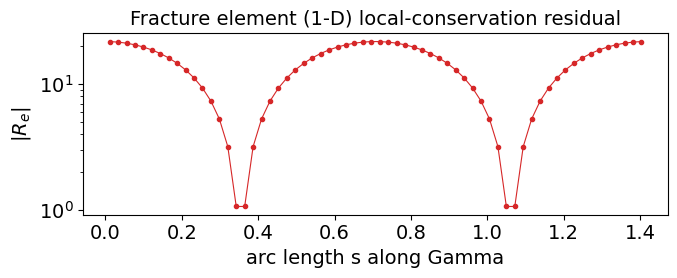

In [37]:
# ============================================================
# CG/LCG-level fracture ELEMENT residual on Gamma.
#   R_e = [q_G(x1) - q_G(x0)] + int_e lambda_h ds - int_e f_G ds,   q_G = -K_F dp_f/ds
# Endpoint flux is the one-sided "inside" value of element e. lambda_h is the RAW
# solved multiplier (assembled coupling is +int lambda*psi); the bulk-diagnostic
# lambda_balance_sign is NOT applied here.
# ============================================================
def compute_fracture_element_residuals(ctx, nq_src=8):
    gamma = ctx["gamma"]
    V_f = ctx["V_f"]
    p_f = ctx["p_f"]
    kf = K_F_VALUE
    try:
        deg = int(ctx["V_f"].element.basix_element.degree)
    except Exception:
        deg = int(order)

    # RAW multiplier evaluator: force the balance sign to +1 so the coefficients
    # are the ones that actually entered the assembled +int lambda*psi block.
    ctx_raw = dict(ctx)
    ctx_raw["lambda_balance_sign"] = 1.0
    lambda_raw = make_lambda_evaluator(ctx_raw)

    frac_a, tau = fracture_origin_tau()

    elem_ = basix.create_element(basix.ElementFamily.P, basix.CellType.interval, deg)
    dphi_end = _tab(elem_, 1, np.array([[0.0], [1.0]]))[1]   # dphi/dr at r=0 and r=1

    xi, wi = np.polynomial.legendre.leggauss(int(nq_src))
    r_src = 0.5 * (xi + 1.0)
    w_src = 0.5 * wi

    tdim = gamma.topology.dim
    gamma.topology.create_connectivity(tdim, 0)
    c2v = gamma.topology.connectivity(tdim, 0)
    geom = gamma.geometry.x[:, :2]
    dofmap = V_f.dofmap
    num_cells = gamma.topology.index_map(tdim).size_local

    rows = []
    R = np.zeros(num_cells, dtype=float)
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        x0 = geom[int(verts[0])]
        x1 = geom[int(verts[1])]
        seg = x1 - x0
        seg_len = float(np.linalg.norm(seg))
        if seg_len == 0.0:
            continue
        coeffs = p_f.x.array[dofmap.cell_dofs(ci)]

        # inside one-sided flux q_G = -K_F dp/ds at the two element ends
        dp_ds_end = (dphi_end @ coeffs) / seg_len
        q_x0 = -kf * float(dp_ds_end[0])
        q_x1 = -kf * float(dp_ds_end[1])
        net_outflux = q_x1 - q_x0

        # raw multiplier integral over the element (arc length)
        lam_int = integrate_lambda_segment(x0, x1, lambda_raw)

        # analytic fracture-source integral over the element (arc length)
        X_phys = x0[None, :] + r_src[:, None] * seg[None, :]
        src_int = seg_len * float(np.dot(w_src, np.asarray(ff_callable(X_phys.T), dtype=float)))

        R_e = net_outflux + lam_int - src_int
        R[ci] = R_e

        s0 = float((x0 - frac_a) @ tau)
        s1 = float((x1 - frac_a) @ tau)
        if s1 < s0:
            s0, s1 = s1, s0
        rows.append({
            "cell": ci, "s0": s0, "s1": s1, "s_mid": 0.5 * (s0 + s1),
            "q_x0": q_x0, "q_x1": q_x1, "net_outflux": net_outflux,
            "lambda_int": lam_int, "source_int": src_int,
            "R_e": R_e, "abs_R_e": abs(R_e),
        })
    return R, rows


run_wall0 = time.perf_counter()
solve_t0 = time.perf_counter()
ctx_demo = solve_lcg_mms(REF_DEMO, verbose=False)
t_solve = time.perf_counter() - solve_t0

gdata_demo = prepare_fracture_geometry(ctx_demo)
print("num cells:", gdata_demo["num_cells"], "h_est:", gdata_demo["h_est"])
print("physical fracture:", gdata_demo["FRAC_A"], "to", gdata_demo["FRAC_B"], "length", gdata_demo["L_gamma"])
if np.allclose(gdata_demo["GHOST_START"], gdata_demo["FRAC_A"]) and np.allclose(gdata_demo["GHOST_END"], gdata_demo["FRAC_B"]):
    print("No ghost extension: the physical fracture spans the domain diagonal.")

frac_t0 = time.perf_counter()
R_frac_elem, frac_elem_rows = compute_fracture_element_residuals(ctx_demo)
t_frac = time.perf_counter() - frac_t0
absR = np.array([r["abs_R_e"] for r in frac_elem_rows], dtype=float)
s_mid = np.array([r["s_mid"] for r in frac_elem_rows], dtype=float)
L_gamma_demo = gdata_demo["L_gamma"]
mask_int = (s_mid >= TIP_FRAC * L_gamma_demo) & (s_mid <= (1.0 - TIP_FRAC) * L_gamma_demo)
q0_vals = np.array([r["q_x0"] for r in frac_elem_rows], dtype=float)
q1_vals = np.array([r["q_x1"] for r in frac_elem_rows], dtype=float)
q_endpoint_vals = np.r_[q0_vals, q1_vals]
net_outflux_vals = np.array([r["net_outflux"] for r in frac_elem_rows], dtype=float)
lambda_int_vals = np.array([r["lambda_int"] for r in frac_elem_rows], dtype=float)
source_int_vals = np.array([r["source_int"] for r in frac_elem_rows], dtype=float)

frac_a_exact, tau_exact = fracture_origin_tau()

def _gamma_points_from_s(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return frac_a_exact[None, :] + s[:, None] * tau_exact[None, :]

def _q_gamma_exact_s(s):
    pts = _gamma_points_from_s(s)
    t = pts[:, 0]
    # p_Gamma(t)=sin^2(pi t), t=x on the full diagonal, and dt/ds=tau_x.
    return -K_F_VALUE * np.pi * tau_exact[0] * np.sin(2.0 * np.pi * t)

def _lambda_exact_s(s):
    pts = _gamma_points_from_s(s)
    return np.asarray(lam_exact_fn(pts[:, 0]), dtype=float).reshape(-1)

def _source_exact_s(s):
    pts = _gamma_points_from_s(s)
    return np.asarray(ff_callable(pts.T), dtype=float).reshape(-1)

def _integrate_exact_s(s0, s1, value_fn, nq=16):
    s0 = float(s0)
    s1 = float(s1)
    if s1 < s0:
        s0, s1 = s1, s0
    if s1 - s0 <= 1.0e-14:
        return 0.0
    xi, wi = np.polynomial.legendre.leggauss(int(nq))
    sq = 0.5 * (s0 + s1) + 0.5 * (s1 - s0) * xi
    return float(0.5 * (s1 - s0) * np.dot(wi, value_fn(sq)))

R_exact_input = []
R_discrete_q_exact_rhs = []
for row in frac_elem_rows:
    s0e, s1e = row["s0"], row["s1"]
    q_exact_flux = float(_q_gamma_exact_s([s1e])[0] - _q_gamma_exact_s([s0e])[0])
    lam_exact_int = _integrate_exact_s(s0e, s1e, _lambda_exact_s)
    src_exact_int = _integrate_exact_s(s0e, s1e, _source_exact_s)
    R_exact_input.append(q_exact_flux + lam_exact_int - src_exact_int)
    R_discrete_q_exact_rhs.append(row["net_outflux"] + lam_exact_int - src_exact_int)
R_exact_input = np.asarray(R_exact_input, dtype=float)
R_discrete_q_exact_rhs = np.asarray(R_discrete_q_exact_rhs, dtype=float)

err_p_gamma_l2, err_p_gamma_h1 = compute_fracture_pressure_errors(ctx_demo)

print("=" * 78)
print(f"CG/LCG fracture element residual, conforming MMS, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
print("=" * 78)
print(f"mesh file            = {ctx_demo['mesh_file']}")
print(f"lambda space         = {ctx_demo['lambda_space']}")
print(f"lambda cells         = {ctx_demo['n_lambda']}  (h_lambda={ctx_demo['h_lambda']:.4e})")
print(f"LCG solve time       = {t_solve:.4f} s")
print(f"R_e diagnostic time  = {t_frac:.4f} s")
print(f"||p_Gamma,h-p_Gamma||_L2 = {err_p_gamma_l2:.6e}")
print(f"|p_Gamma,h-p_Gamma|_H1   = {err_p_gamma_h1:.6e}")
print("Fracture element residual R_e = [q_G(x1)-q_G(x0)] + int_e lambda_h ds - int_e f_G ds")
print("  sign convention: net tangential flux out - int_e f_G ds + int_e lambda_h ds")
print("  flux in R_e is raw CG fracture flux q_Gamma,h = -K_F d_s p_Gamma,h from the local element")
print(f"  q_Gamma,h endpoint min/max = {q_endpoint_vals.min():.6e}, {q_endpoint_vals.max():.6e}")
print(f"  |q_Gamma,h| endpoint mean/max = {np.mean(np.abs(q_endpoint_vals)):.6e}, {np.max(np.abs(q_endpoint_vals)):.6e}")
print(f"  |q_Gamma,h(s1)-q_Gamma,h(s0)| mean/max = {np.mean(np.abs(net_outflux_vals)):.6e}, {np.max(np.abs(net_outflux_vals)):.6e}")
print(f"  |int_e f_Gamma ds| mean/max = {np.mean(np.abs(source_int_vals)):.6e}, {np.max(np.abs(source_int_vals)):.6e}")
print(f"  |int_e lambda_h ds| mean/max = {np.mean(np.abs(lambda_int_vals)):.6e}, {np.max(np.abs(lambda_int_vals)):.6e}")
print(f"  exact q/lambda/source test mean/max |R_e| = {np.mean(np.abs(R_exact_input)):.6e}, {np.max(np.abs(R_exact_input)):.6e}")
print(f"  discrete q + exact lambda/source mean/max |R_e| = {np.mean(np.abs(R_discrete_q_exact_rhs)):.6e}, {np.max(np.abs(R_discrete_q_exact_rhs)):.6e}")
print(f"  fracture elements = {len(frac_elem_rows)}")
print(f"  mean |R_e|        = {absR.mean():.6e}")
print(f"  max  |R_e|        = {absR.max():.6e}")
if np.any(mask_int):
    print(f"  interior mean     = {absR[mask_int].mean():.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
    print(f"  interior max      = {absR[mask_int].max():.6e}")
print(f"  lambda balance sign = {ctx_demo['lambda_balance_sign']:+.0f}  (raw lmbd used; sign flag intentionally NOT applied)")
print("=" * 78)

try:
    import pandas as pd
    frac_elem_table = pd.DataFrame(frac_elem_rows)
    display(frac_elem_table.head(12))
except Exception:
    frac_elem_table = frac_elem_rows
    print(frac_elem_rows[:5])

try:
    idx = np.argsort(s_mid)
    plt.figure(figsize=(7, 3))
    plt.semilogy(s_mid[idx], absR[idx] + 1e-30, "o-", ms=3, lw=0.8, color="tab:red")
    plt.xlabel("arc length s along Gamma")
    plt.ylabel(r"$|R_e|$")
    plt.title("Fracture element (1-D) local-conservation residual")
    plt.tight_layout()
    plt.show()
except Exception as _e:
    print("plot skipped:", _e)


## 2. Optional Deng reconstruction reference run and residual assembly


In [38]:
if not RUN_DENG_DEMO:
    print('Deng reconstruction demo skipped (RUN_DENG_DEMO=False). The CG/LCG fracture element residual above does not need Deng post-processing.')
else:
    run_wall0 = time.perf_counter()

    solve_t0 = time.perf_counter()
    ctx_demo = solve_lcg_mms(REF_DEMO, verbose=False)
    t_solve = time.perf_counter() - solve_t0

    gdata_demo = prepare_fracture_geometry(ctx_demo)
    print("num cells:", gdata_demo["num_cells"], "h_est:", gdata_demo["h_est"])
    print("physical fracture:", gdata_demo["FRAC_A"], "to", gdata_demo["FRAC_B"], "length", gdata_demo["L_gamma"])
    if np.allclose(gdata_demo["GHOST_START"], gdata_demo["FRAC_A"]) and np.allclose(gdata_demo["GHOST_END"], gdata_demo["FRAC_B"]):
        print("No ghost extension: the physical fracture spans the domain diagonal.")

    post_t0 = time.perf_counter()
    lf_demo, coef_demo, p_rec_demo = deng_postprocess_fracture(ctx_demo)
    t_post = time.perf_counter() - post_t0

    diag_t0 = time.perf_counter()
    R_elem_cg, lambda_cell_demo, frac_cell_ids, gamma_cell_records = compute_lce_per_element_fracture(
        ctx_demo, lf_demo, gdata_demo, use_rec=False
    )
    R_elem_rec, _, _, _ = compute_lce_per_element_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
    R_cv_cg, lambda_cv_demo, fracture_dof_demo = compute_lce_per_cv_fracture(
        ctx_demo, lf_demo, gdata_demo, use_rec=False
    )
    R_cv_rec, _, _ = compute_lce_per_cv_fracture(ctx_demo, lf_demo, gdata_demo, use_rec=True)
    t_diag = time.perf_counter() - diag_t0

    is_bnd_demo = boundary_dof_mask(ctx_demo)
    cv_coords_demo = ctx_demo["V"].tabulate_dof_coordinates()[:, :2]
    interior_cv_ids = np.where(~is_bnd_demo)[0]
    fracture_cv_ids = np.where(fracture_dof_demo & (~is_bnd_demo))[0]
    nonfracture_cv_ids = np.where((~fracture_dof_demo) & (~is_bnd_demo))[0]

    err_p_cg_l2, err_p_cg_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=False)
    err_p_rec_l2, err_p_rec_h1 = compute_pressure_errors(ctx_demo, lf_demo, gdata_demo, use_rec=True)
    err_p_gamma_l2, err_p_gamma_h1 = compute_fracture_pressure_errors(ctx_demo)
    err_q_cg = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=False)
    err_q_rec = compute_q_l2_local(ctx_demo, lf_demo, gdata_demo, use_rec=True)
    err_lam_jump_cg = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=False)
    err_lam_jump_rec = compute_lambda_jump_l2(ctx_demo, lf_demo, gdata_demo, use_rec=True)

    total_computation_time = time.perf_counter() - run_wall0

    print("=" * 78)
    print(f"Deng CV reconstruction, conforming fracture MMS, ref={REF_DEMO}, h={ctx_demo['h']:.4e}")
    print("=" * 78)
    print(f"mesh file                    = {ctx_demo['mesh_file']}")
    print(f"Newton iterations            = {ctx_demo['iterations']}")
    print(f"matrix DOFs                  = {ctx_demo['dofs']}")
    print(f"lambda space                 = {ctx_demo['lambda_space']}")
    print(f"lambda cells                 = {ctx_demo['n_lambda']}  (h_lambda={ctx_demo['h_lambda']:.4e})")
    print(f"total LCG DOFs               = {ctx_demo['dofs_total']}")
    print(f"lambda balance sign          = {ctx_demo['lambda_balance_sign']:+.0f}")
    print(f"LCG solve time               = {t_solve:.4f} s")
    print(f"Deng post-processing time    = {t_post:.4f} s")
    print(f"Residual diagnostic time     = {t_diag:.4f} s")
    print(f"Total computation time       = {total_computation_time:.4f} s")
    print(f"||p_h - p_m_exact||_L2       = {err_p_cg_l2:.6e}")
    print(f"|p_h - p_m_exact|_H1         = {err_p_cg_h1:.6e}")
    print(f"||p_Deng - p_m_exact||_L2    = {err_p_rec_l2:.6e}")
    print(f"|p_Deng - p_m_exact|_H1      = {err_p_rec_h1:.6e}")
    print(f"||p_Gamma,h - p_Gamma||_L2  = {err_p_gamma_l2:.6e}")
    print(f"|p_Gamma,h - p_Gamma|_H1    = {err_p_gamma_h1:.6e}")
    print(f"||lambda_h - lambda||_L2     = {ctx_demo['err_lam']:.6e}")
    print(f"||jump(v_h) - lambda||_L2    = {err_lam_jump_cg:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
    print(f"||jump(v_Deng) - lambda||_L2 = {err_lam_jump_rec:.6e}  (excluding {TIP_FRAC*100:.0f}% tips)")
    print(f"||v_h - v_exact||_L2         = {err_q_cg:.6e}")
    print(f"||v_Deng - v_exact||_L2      = {err_q_rec:.6e}")
    print("=" * 78)


Deng reconstruction demo skipped (RUN_DENG_DEMO=False). The CG/LCG fracture element residual above does not need Deng post-processing.


## 3. Optional Deng jump diagnostic


In [39]:
if not RUN_DENG_DEMO or "lf_demo" not in globals():
    print('Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.')
else:
    def cg_jump_on_fracture(ctx, gdata, s_query, eps=None):
        if eps is None:
            eps = 0.1 * gdata["h_est"]
        s_query = np.asarray(s_query, dtype=float).reshape(-1)
        x0 = gdata["real_points_np"](s_query)
        normal = gdata["normal_np"]
        qp = q_cg_numpy(ctx, gdata, x0 + eps * normal[None, :])
        qm = q_cg_numpy(ctx, gdata, x0 - eps * normal[None, :])
        return np.sum((qp - qm) * normal[None, :], axis=1)


    def deng_jump_on_fracture(ctx, local_fluxes, gdata, s_query, eps=None):
        if eps is None:
            eps = 0.1 * gdata["h_est"]
        s_query = np.asarray(s_query, dtype=float).reshape(-1)
        x0 = gdata["real_points_np"](s_query)
        normal = gdata["normal_np"]
        qp = q_rec_numpy(ctx, local_fluxes, gdata, x0 + eps * normal[None, :])
        qm = q_rec_numpy(ctx, local_fluxes, gdata, x0 - eps * normal[None, :])
        return np.sum((qp - qm) * normal[None, :], axis=1)


    N_REAL = max(128, 4 * len(ctx_demo["gamma_entities"]))
    s_real = np.linspace(0.0, gdata_demo["L_gamma"], N_REAL)
    x_real = gdata_demo["real_points_np"](s_real)
    lambda_h_real = lambda_h_on_s(ctx_demo, gdata_demo, s_real)
    lambda_exact_real = lam_exact_fn(x_real[:, 0])

    # Use P0 multiplier interval midpoints for CG and Deng jump comparison.
    s_nodes_jump = np.asarray(ctx_demo.get("lambda_s_nodes", []), dtype=float)
    if len(s_nodes_jump) < 2:
        dof_points_jump = ctx_demo["V_l"].tabulate_dof_coordinates()[:, :2]
        s_nodes_jump = np.unique(np.round(np.sort(gdata_demo["s_coord_np"](dof_points_jump)), decimals=14))
    s_mid_jump = 0.5 * (s_nodes_jump[:-1] + s_nodes_jump[1:])
    x_mid_jump = gdata_demo["real_points_np"](s_mid_jump)
    lambda_exact_mid = lam_exact_fn(x_mid_jump[:, 0])
    jump_cg_mid = cg_jump_on_fracture(ctx_demo, gdata_demo, s_mid_jump)
    jump_deng_mid = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_mid_jump)

    fig, ax = plt.subplots(figsize=(9.0, 4.4), constrained_layout=True)
    ax.plot(s_real, lambda_exact_real, color="0.10", lw=2.0, label=r"$\lambda$")
    ax.scatter(s_real[::max(N_REAL // 34, 1)], lambda_h_real[::max(N_REAL // 34, 1)],
               s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3, label=r"$\lambda_h$")
    ax.plot(s_mid_jump, jump_cg_mid, "--", color="tab:blue", lw=1.7, marker="x", ms=4.5,
            markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]$")
    ax.plot(s_mid_jump, jump_deng_mid, "-", color="tab:orange", lw=1.8, marker="o", ms=4.2,
            mfc="white", markevery=max(len(s_mid_jump) // 34, 1), label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]$")
    ax.axvline(0.0, color="k", ls="--", lw=0.8)
    ax.axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
    ax.axhline(0.0, color="0.35", lw=0.7)
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"jump")
    ax.set_ylim([-2.2,0.5])
    ax.grid(False)
    ax.legend(frameon=False, ncol=2, handlelength=2.0)
    plt.show()

    fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
    ax.plot(s_mid_jump, jump_cg_mid - lambda_exact_mid, "--", color="tab:blue", lw=1.7,
            marker="x", ms=4.5, markevery=max(len(s_mid_jump) // 34, 1),
            label=r"$[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
    ax.plot(s_mid_jump, jump_deng_mid - lambda_exact_mid, "-", color="tab:orange", lw=1.8,
            marker="o", ms=4.2, mfc="white", markevery=max(len(s_mid_jump) // 34, 1),
            label=r"$[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]-\lambda$")
    ax.scatter(s_real[::max(N_REAL // 34, 1)], (lambda_h_real - lambda_exact_real)[::max(N_REAL // 34, 1)],
               s=30, facecolors="none", edgecolors="tab:red", linewidths=1.3,
               label=r"$\lambda_h-\lambda$")
    ax.axhline(0.0, color="0.35", lw=0.7)
    ax.set_xlabel(r"$s$")
    ax.set_ylabel("error")
    ax.grid(False)
    ax.legend(frameon=False, handlelength=2.0)
    plt.show()

    mask_mid = (s_mid_jump >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_mid_jump <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
    mask_real = (s_real >= TIP_FRAC * gdata_demo["L_gamma"]) & (s_real <= (1.0 - TIP_FRAC) * gdata_demo["L_gamma"])
    err_cg_jump = jump_cg_mid[mask_mid] - lambda_exact_mid[mask_mid]
    err_deng_jump = jump_deng_mid[mask_mid] - lambda_exact_mid[mask_mid]
    err_lh = lambda_h_real[mask_real] - lambda_exact_real[mask_real]
    print(f"Real fracture jump vs lambda_exact (excluding {TIP_FRAC*100:.0f}% tips):")
    print(f"  CG    max={np.max(np.abs(err_cg_jump)):.3e}  mean={np.mean(np.abs(err_cg_jump)):.3e}  L2={np.sqrt(np.trapezoid(err_cg_jump**2, s_mid_jump[mask_mid])):.3e}")
    print(f"  Deng  max={np.max(np.abs(err_deng_jump)):.3e}  mean={np.mean(np.abs(err_deng_jump)):.3e}  L2={np.sqrt(np.trapezoid(err_deng_jump**2, s_mid_jump[mask_mid])):.3e}")
    print(f"  lam_h max={np.max(np.abs(err_lh)):.3e}  mean={np.mean(np.abs(err_lh)):.3e}  L2={np.sqrt(np.trapezoid(err_lh**2, s_real[mask_real])):.3e}")

    # Ghost-extension jump magnitude. For the full-diagonal MMS this block prints
    # that no ghost extension is present.
    x_ghost = gdata_demo["ghost_points_np"](n_each=max(64, N_REAL // 2))
    if len(x_ghost):
        s_ghost = gdata_demo["s_coord_np"](x_ghost)
        jump_cg_ghost = cg_jump_on_fracture(ctx_demo, gdata_demo, s_ghost)
        jump_deng_ghost = deng_jump_on_fracture(ctx_demo, lf_demo, gdata_demo, s_ghost)
        fig, ax = plt.subplots(figsize=(8.6, 4.2), constrained_layout=True)
        ax.semilogy(s_ghost, np.abs(jump_cg_ghost) + 1e-30, "--", color="tab:blue", lw=1.7,
                    label=r"$|[\![\mathbf{v}_h\cdot\mathbf{n}_\Gamma]\!]|$")
        ax.semilogy(s_ghost, np.abs(jump_deng_ghost) + 1e-30, "-", color="tab:orange", lw=1.8,
                    label=r"$|[\![\mathbf{v}_D\cdot\mathbf{n}_\Gamma]\!]|$")
        ax.set_xlabel(r"$s$")
        ax.set_ylabel("magnitude")
        ax.grid(True, which="both", alpha=0.22)
        ax.legend(frameon=False, handlelength=2.0)
        plt.show()
    else:
        print("No ghost extension: the physical fracture spans the full domain diagonal.")


Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.


## 4. Optional Deng residual maps: element-wise and control-volume-wise


In [40]:
if not RUN_DENG_DEMO or "R_elem_rec" not in globals():
    print('Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.')
else:
    def _log_res(values, eps=1e-30):
        return np.log10(np.abs(values) + eps)


    def _map_extend(log_values):
        lo = np.nanmin(log_values)
        hi = np.nanmax(log_values)
        if lo < RK_LOG_VMIN and hi > RK_LOG_VMAX:
            return "both"
        if lo < RK_LOG_VMIN:
            return "min"
        if hi > RK_LOG_VMAX:
            return "max"
        return "neither"


    cent = gdata_demo["cell_centroids"]
    cv_xy = cv_coords_demo
    cv_plot_ids = interior_cv_ids
    map_specs = [
        ("Element", r"$R_K(\mathbf{v}_h)$", cent, R_elem_cg),
        ("Element", r"$R_K(\mathbf{v}_D)$", cent, R_elem_rec),
        ("CV", r"$R_\xi(\mathbf{v}_h)$", cv_xy[cv_plot_ids], R_cv_cg[cv_plot_ids]),
        ("CV", r"$R_\xi(\mathbf{v}_D)$", cv_xy[cv_plot_ids], R_cv_rec[cv_plot_ids]),
    ]
    all_logs = np.concatenate([_log_res(vals) for _, _, _, vals in map_specs])
    extend = _map_extend(all_logs)

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.0), constrained_layout=True)
    for ax, (kind, title, xy, vals) in zip(axes.ravel(), map_specs):
        sc = ax.scatter(
            xy[:, 0], xy[:, 1], c=_log_res(vals), s=8 if kind == "Element" else 10,
            cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
            linewidths=0.0, rasterized=True,
        )
        plot_fracture_lines(ax, gdata_demo)
        ax.set_aspect("equal")
        ax.set_xlim(-0.02, 1.02)
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(title)
        ax.grid(False)
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        cbar = fig.colorbar(sc, ax=ax, label=r"$\log_{10}|R|$", extend=extend, pad=0.02)
        cbar.set_ticks(RK_CBAR_TICKS)
    plt.show()

    # Distribution over all matrix cells and all interior CVs.
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
    lo_e = min(_log_res(R_elem_cg).min(), _log_res(R_elem_rec).min())
    hi_e = max(_log_res(R_elem_cg).max(), _log_res(R_elem_rec).max())
    bins_e = np.linspace(lo_e, hi_e, 45)
    axes[0].hist(_log_res(R_elem_cg), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
    axes[0].hist(_log_res(R_elem_rec), bins=bins_e, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
    axes[0].set_xlabel(r"$\log_{10}|R_K|$")
    axes[0].set_ylabel("# of cells")
    axes[0].grid(False)
    axes[0].legend(frameon=False)

    lo_cv = min(_log_res(R_cv_cg[interior_cv_ids]).min(), _log_res(R_cv_rec[interior_cv_ids]).min())
    hi_cv = max(_log_res(R_cv_cg[interior_cv_ids]).max(), _log_res(R_cv_rec[interior_cv_ids]).max())
    bins_cv = np.linspace(lo_cv, hi_cv, 45)
    axes[1].hist(_log_res(R_cv_cg[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_h$", color="tab:blue")
    axes[1].hist(_log_res(R_cv_rec[interior_cv_ids]), bins=bins_cv, alpha=0.58, label=r"$\mathbf{v}_D$", color="tab:orange")
    axes[1].set_xlabel(r"$\log_{10}|R_\xi|$")
    axes[1].set_ylabel("# of interior CVs")
    axes[1].grid(False)
    axes[1].legend(frameon=False)
    plt.show()


Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.


## 5. Optional Deng quantitative comparison table


In [41]:
if not RUN_DENG_DEMO or "R_elem_rec" not in globals():
    print('Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.')
else:
    def print_stats_block(label, before, after, ids_all, ids_focus, focus_label):
        b_all = residual_stats(before, ids_all)
        a_all = residual_stats(after, ids_all)
        b_focus = residual_stats(before, ids_focus)
        a_focus = residual_stats(after, ids_focus)
        imp = improvement_stats(before, after, ids_focus)

        print(label)
        print(f"  all/interior count     = {b_all['n']}")
        print(f"  focus count ({focus_label}) = {b_focus['n']}")
        print(f"  CG    mean={b_all['mean']:.3e} median={b_all['median']:.3e} max={b_all['max']:.3e} | focus mean={b_focus['mean']:.3e} max={b_focus['max']:.3e}")
        print(f"  Deng  mean={a_all['mean']:.3e} median={a_all['median']:.3e} max={a_all['max']:.3e} | focus mean={a_focus['mean']:.3e} max={a_focus['max']:.3e}")
        print(f"  focus improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")
        print()
        return b_all, a_all, b_focus, a_focus, imp


    all_cell_ids = np.arange(gdata_demo["num_cells"], dtype=np.int32)
    print("Quantitative local-conservation comparison")
    print(f"ref={REF_DEMO}, h={ctx_demo['h']:.4e}, total computation time={total_computation_time:.4f} s")
    print()
    elem_stats = print_stats_block(
        "Element-wise residual R_K",
        R_elem_cg, R_elem_rec, all_cell_ids, frac_cell_ids, "fracture-adjacent cells"
    )
    cv_stats = print_stats_block(
        "Control-volume residual R_xi",
        R_cv_cg, R_cv_rec, interior_cv_ids, fracture_cv_ids, "interior fracture CVs"
    )


Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.


## 6. Optional Deng local conservation around the fracture


In [42]:
if not RUN_DENG_DEMO or "R_elem_rec" not in globals():
    print('Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.')
else:
    cent_frac = gdata_demo["cell_centroids"][frac_cell_ids]
    s_elem_frac = gdata_demo["s_coord_np"](cent_frac) if len(frac_cell_ids) else np.array([])
    cv_frac_xy = cv_coords_demo[fracture_cv_ids]
    s_cv_frac = gdata_demo["s_coord_np"](cv_frac_xy) if len(fracture_cv_ids) else np.array([])

    print(f"Fracture-adjacent cells      : {len(frac_cell_ids)}")
    print(f"Interior fracture CV dofs: {len(fracture_cv_ids)}")

    fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.0), constrained_layout=True)
    if len(frac_cell_ids):
        sc0 = axes[0].scatter(
            cent_frac[:, 0], cent_frac[:, 1], c=_log_res(R_elem_rec[frac_cell_ids]),
            s=40, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
            edgecolors="k", linewidths=0.2, rasterized=True,
        )
        plot_fracture_lines(axes[0], gdata_demo)
        axes[0].set_title(r"Fracture-adjacent $|R_K(\mathbf{v}_D)|$")
        axes[0].set_aspect("equal")
        axes[0].grid(False)
        fig.colorbar(sc0, ax=axes[0], label=r"$\log_{10}|R_K|$", pad=0.02)
    else:
        axes[0].set_title("No fracture-adjacent cells")

    if len(fracture_cv_ids):
        sc1 = axes[1].scatter(
            cv_frac_xy[:, 0], cv_frac_xy[:, 1], c=_log_res(R_cv_rec[fracture_cv_ids]),
            s=42, cmap="RdBu_r", vmin=RK_LOG_VMIN, vmax=RK_LOG_VMAX,
            edgecolors="k", linewidths=0.2, rasterized=True,
        )
        plot_fracture_lines(axes[1], gdata_demo)
        axes[1].set_title(r"Interior fracture-CV $|R_\xi(\mathbf{v}_D)|$")
        axes[1].set_aspect("equal")
        axes[1].grid(False)
        fig.colorbar(sc1, ax=axes[1], label=r"$\log_{10}|R_\xi|$", pad=0.02)
    else:
        axes[1].set_title("No interior fracture CVs")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), constrained_layout=True)
    if len(frac_cell_ids):
        idx = np.argsort(s_elem_frac)
        axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_cg[frac_cell_ids][idx]) + 1e-30,
                         "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
        axes[0].semilogy(s_elem_frac[idx], np.abs(R_elem_rec[frac_cell_ids][idx]) + 1e-30,
                         "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
        axes[0].axvline(0.0, color="k", ls="--", lw=0.8)
        axes[0].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
        axes[0].set_xlabel(r"$s$")
        axes[0].set_ylabel(r"$|R_K|$")
        axes[0].set_title("Element-wise")
        axes[0].grid(True, which="both", alpha=0.22)
        axes[0].legend(frameon=False)

    if len(fracture_cv_ids):
        idx = np.argsort(s_cv_frac)
        axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_cg[fracture_cv_ids][idx]) + 1e-30,
                         "o-", ms=4, lw=1.4, label=r"$\mathbf{v}_h$")
        axes[1].semilogy(s_cv_frac[idx], np.abs(R_cv_rec[fracture_cv_ids][idx]) + 1e-30,
                         "s-", ms=4, lw=1.4, label=r"$\mathbf{v}_D$")
        axes[1].axvline(0.0, color="k", ls="--", lw=0.8)
        axes[1].axvline(gdata_demo["L_gamma"], color="k", ls="--", lw=0.8)
        axes[1].set_xlabel(r"$s$")
        axes[1].set_ylabel(r"$|R_\xi|$")
        axes[1].set_title("Control-volume-wise")
        axes[1].grid(True, which="both", alpha=0.22)
        axes[1].legend(frameon=False)
    plt.show()

    for label, before, after, ids in [
        ("Fracture-adjacent element residuals", R_elem_cg, R_elem_rec, frac_cell_ids),
        ("Interior fracture-CV residuals", R_cv_cg, R_cv_rec, fracture_cv_ids),
    ]:
        b = residual_stats(before, ids)
        a = residual_stats(after, ids)
        imp = improvement_stats(before, after, ids)
        print(f"\n{label} (n={b['n']}):")
        print(f"  CG    mean={b['mean']:.3e} median={b['median']:.3e} max={b['max']:.3e}")
        print(f"  Deng  mean={a['mean']:.3e} median={a['median']:.3e} max={a['max']:.3e}")
        print(f"  improved={imp[0]:.1f}% ratio mean={imp[1]:.3e} median={imp[2]:.3e} max={imp[3]:.3e}")


Skipped: set RUN_DENG_DEMO=True and run the optional Deng reference section first.
